In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [2]:
# 1. Load run-level metrics
csv_path = "../../../Results/Tessnim/all_subjects_yeo17_metrics.csv"
df = pd.read_csv(csv_path)

df["normalized_segregation"] = (
    (df["segregation"] - df["integration"]) / df["segregation"]
)

FIGURES_DIR = "../../../Results/Tessnim/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# CSV already stores r-space values (tanh applied during computation)
df["segregation_r"] = df["segregation"]
df["integration_r"] = df["integration"]

# If normalized_segregation already exists in df, we just keep it
# (otherwise, comment it out from metrics list below)

level = "network"
group_cols = ["subject", "session", "run", "condition"]
if level == "network":
    group_cols += ["network"]

df_run = (
    df.groupby(group_cols, as_index=False)[
        ["segregation", "integration", "segregation_r", "integration_r", "normalized_segregation"]
    ].mean()
)

This cell compares the distribution of a metric (e.g. segregation) between Feedback and Transfer runs using a **bootstrapped, matched-size** approach:

1. **Extract raw values and sizes**  
   We take the metric values for feedback (`values_fb`) and transfer (`values_tr`), and store their sample sizes as `n_fb` and `n_tr`. This gives us the two distributions we want to compare.

2. **Define common histogram bins**  
   We set `bins = 40` and define `bin_edges` from the global min to the global max across both conditions. Using the same bin edges ensures that Feedback and Transfer histograms are directly comparable.

3. **Bootstrap matched-size feedback samples**  
   We perform `n_boot = 500` iterations. In each iteration:
   - We randomly select `n_tr` feedback values (without replacement) using `rng.choice`.
   - We compute a histogram for this subsample (`np.histogram`) using the fixed `bin_edges` and with `density=True` to obtain a probability density.
   - We accumulate the bin counts into `hist_fb_accum`.

4. **Average feedback histogram across bootstraps**  
   After all iterations, we divide `hist_fb_accum` by `n_boot` to obtain `hist_fb_mean`, which is the average density in each bin over many matched-size subsamples. This reduces the randomness that would come from plotting a single arbitrary subsample.

5. **Compute transfer histogram once**  
   For the Transfer condition, we compute a single histogram (`counts_tr`) using all `values_tr` and the same `bin_edges`. The resulting `counts_tr` is directly comparable to `hist_fb_mean`.

6. **Plot bootstrapped feedback vs transfer**  
   We compute `bin_centers` for visualization, then:
   - Plot `hist_fb_mean` as a smooth line for Feedback (bootstrapped, matched-size).
   - Plot `counts_tr` as a step histogram for Transfer.
   This shows how the typical feedback distribution would look if it had the same number of samples as the transfer condition, while reducing dependence on one particular random subsample.

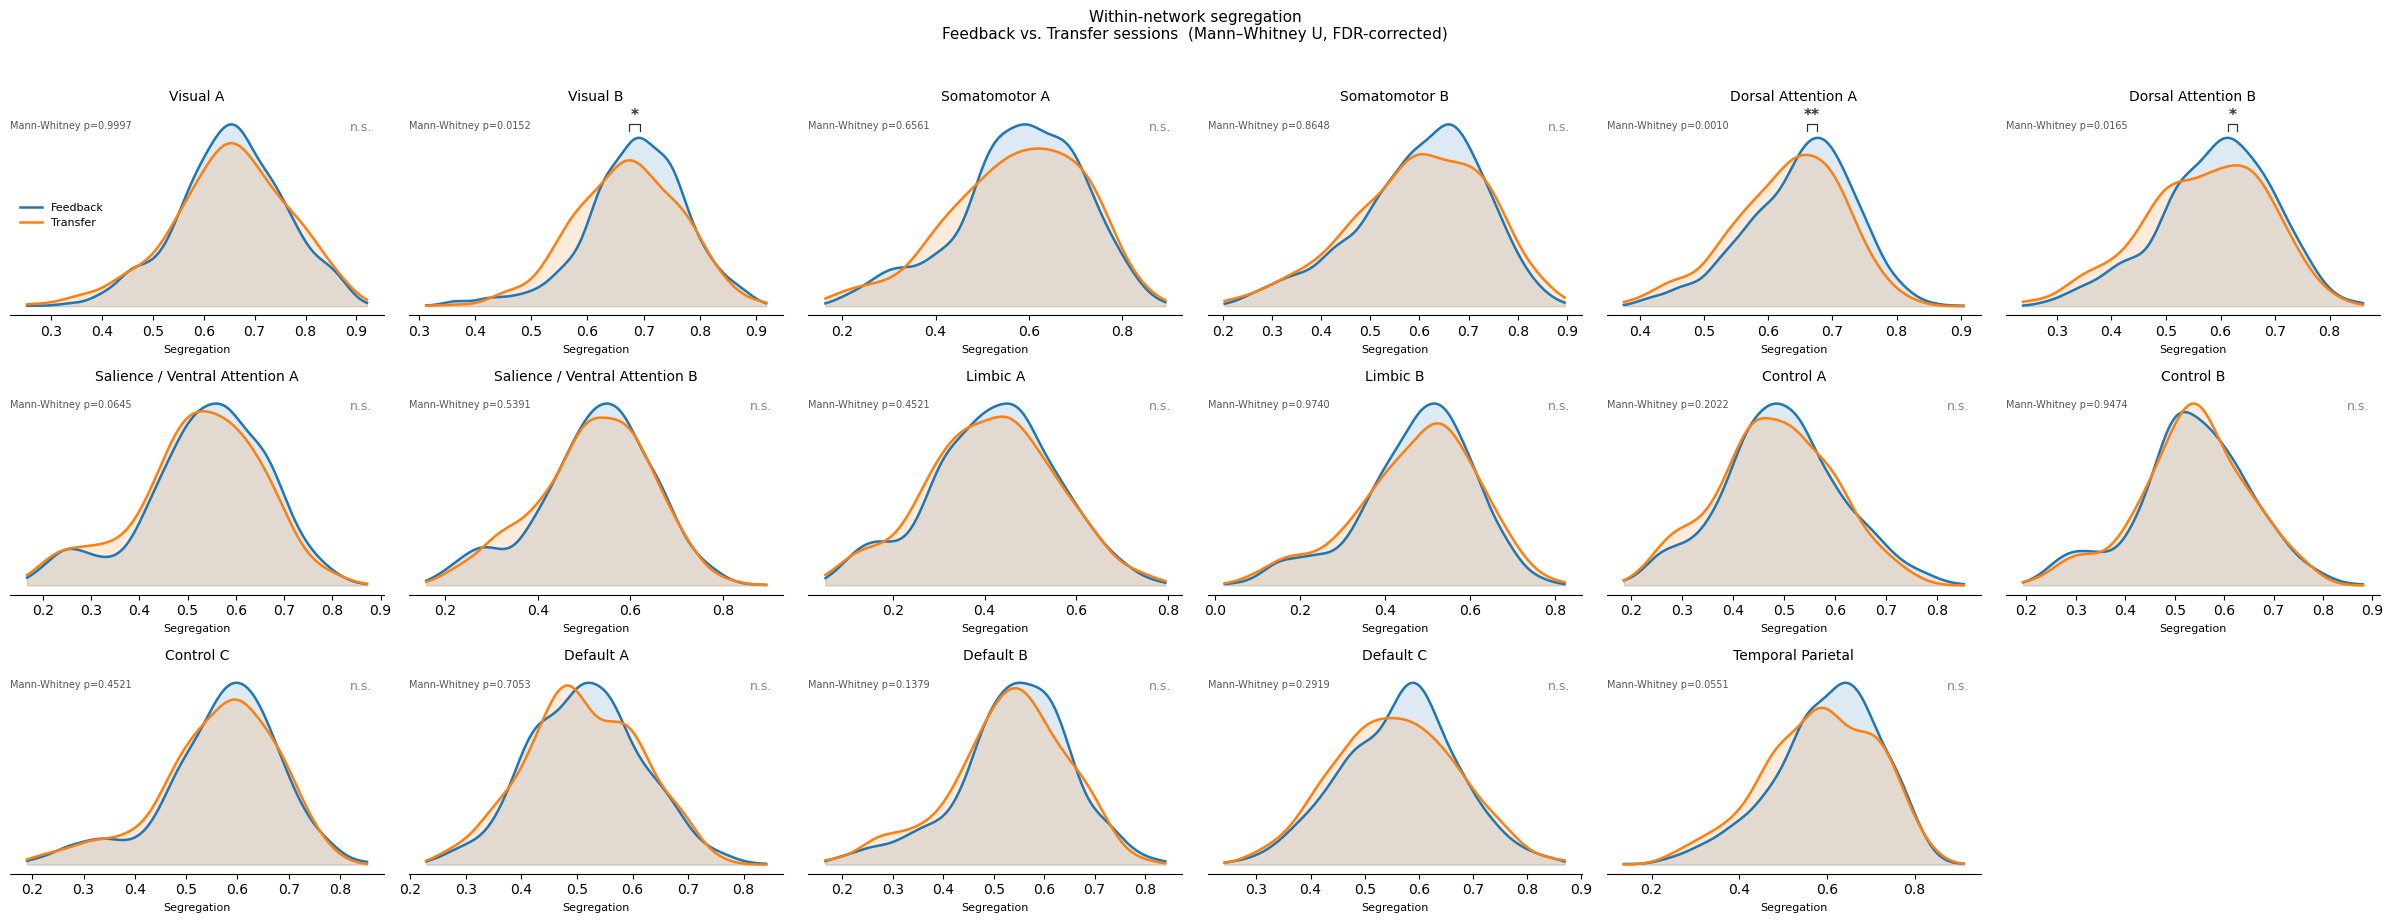

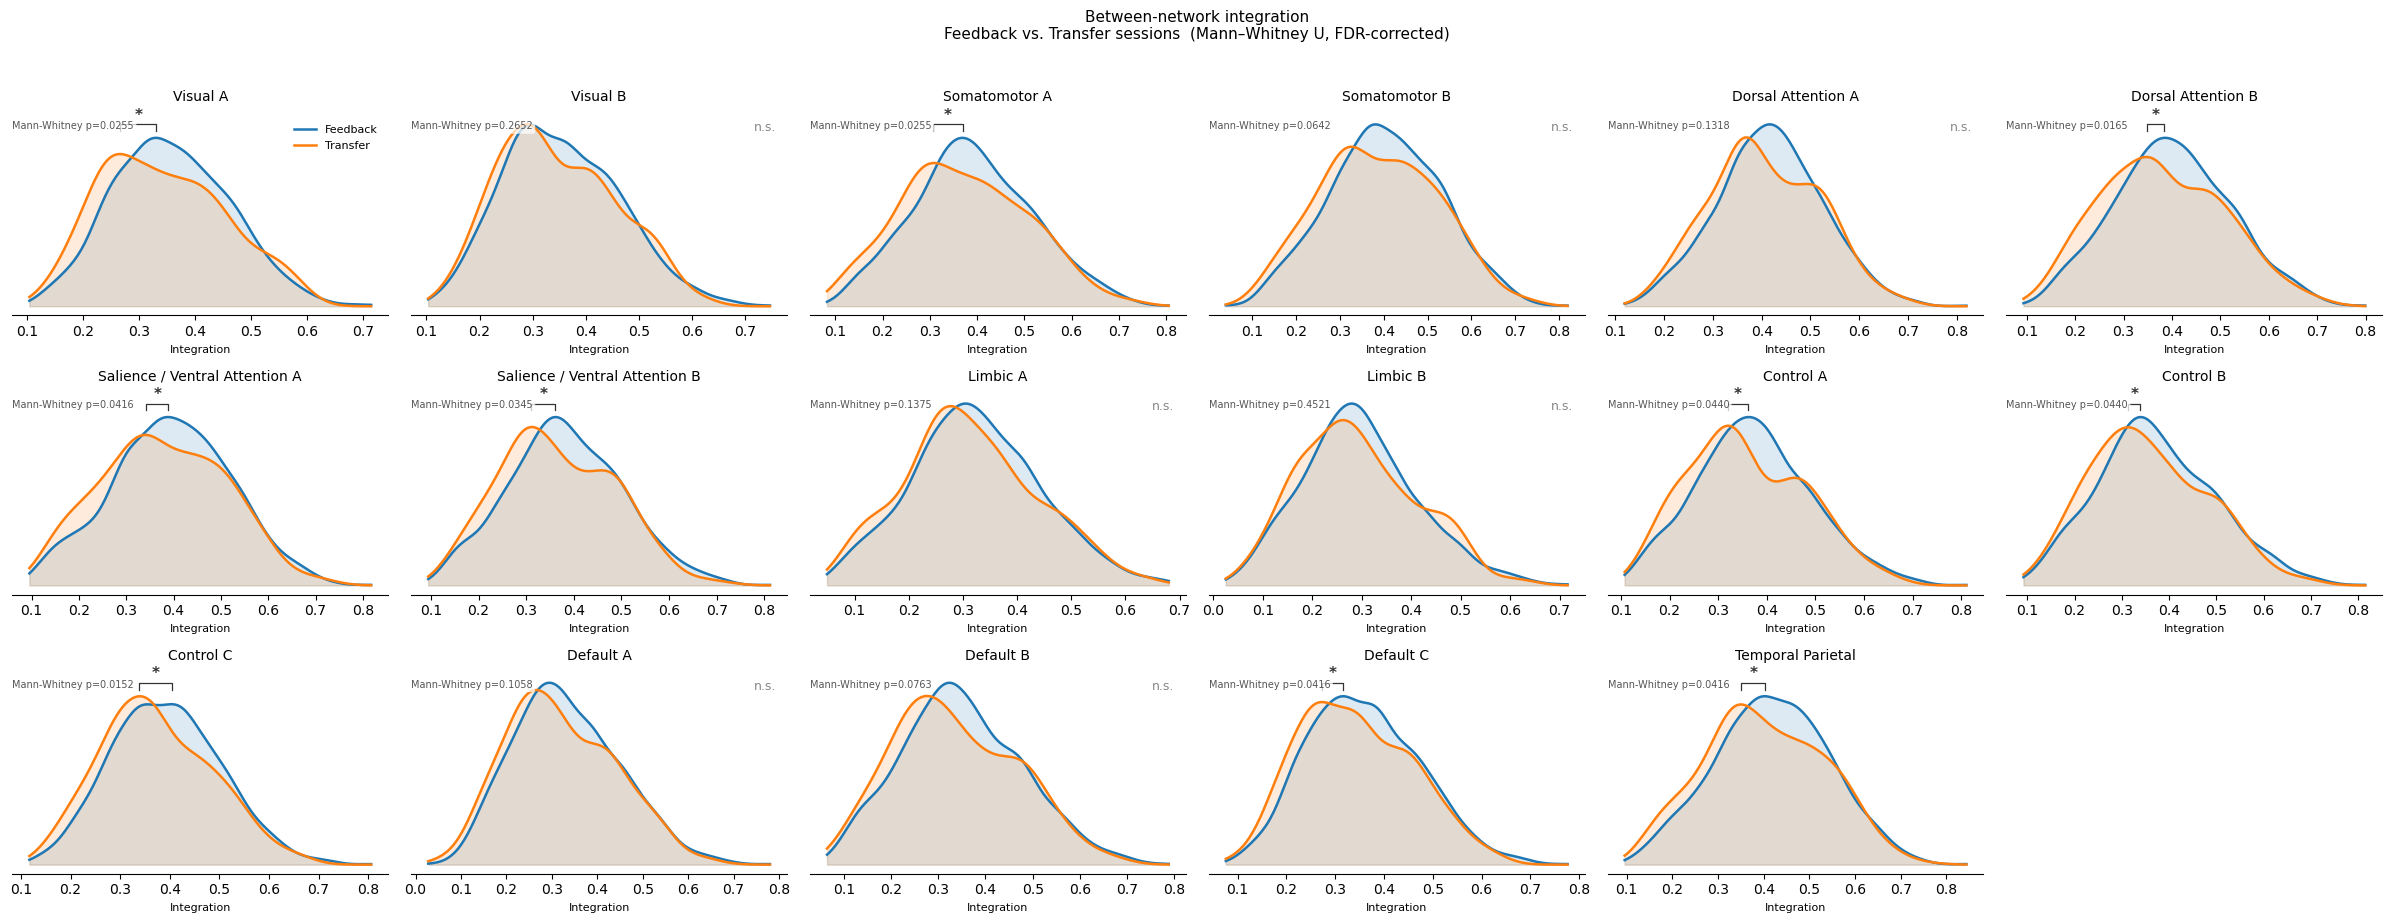

In [15]:
from scipy.stats import gaussian_kde, mannwhitneyu
from statsmodels.stats.multitest import multipletests

YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO17_NAME_MAP = {
    "VisCent": "Visual A", "VisPeri": "Visual B",
    "SomMotA": "Somatomotor A", "SomMotB": "Somatomotor B",
    "DorsAttnA": "Dorsal Attention A", "DorsAttnB": "Dorsal Attention B",
    "SalVentAttnA": "Salience / Ventral Attention A", "SalVentAttnB": "Salience / Ventral Attention B",
    "LimbicA": "Limbic A", "LimbicB": "Limbic B",
    "ContA": "Control A", "ContB": "Control B", "ContC": "Control C",
    "DefaultA": "Default A", "DefaultB": "Default B", "DefaultC": "Default C",
    "TempPar": "Temporal Parietal",
}
net_ids = [n for n in YEO17_ORDER if n in set(df_run["network"].unique())]
net_name = {net: YEO17_NAME_MAP[net] for net in net_ids}

metrics = ["segregation_r", "integration_r"]

metric_titles = {
    "segregation_r": "Within-network segregation",
    "integration_r": "Between-network integration",
}
metric_xlabels = {
    "segregation_r": "Segregation",
    "integration_r": "Integration",
}

def p_to_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "n.s."

# ── PASS 1: fit KDE on full data + collect raw MW p-values ──────────
keys     = []
raw_mw   = []
kde_data = {}

for metric in metrics:
    for net in net_ids:
        df_net    = df_run[df_run["network"] == net]
        values_fb = df_net[df_net["condition"] == "Feedback"][metric].values
        values_tr = df_net[df_net["condition"] == "Transfer"][metric].values

        if values_fb.size < 5 or values_tr.size < 5:
            kde_data[(metric, net)] = None
            continue

        _, mw_p = mannwhitneyu(values_fb, values_tr, alternative="two-sided")

        vmin   = min(values_fb.min(), values_tr.min())
        vmax   = max(values_fb.max(), values_tr.max())
        x_grid = np.linspace(vmin, vmax, 200)

        kde_data[(metric, net)] = {
            "x_grid":   x_grid,
            "dens_fb":  gaussian_kde(values_fb)(x_grid),
            "dens_tr":  gaussian_kde(values_tr)(x_grid),
            "mw_p_raw": mw_p,
        }
        keys.append((metric, net))
        raw_mw.append(mw_p)

# ── FDR correction across all valid tests ───────────────────────────
reject, p_corrected, _, _ = multipletests(raw_mw, method="fdr_bh")

for (metric, net), p_corr, rej in zip(keys, p_corrected, reject):
    kde_data[(metric, net)]["mw_p_corr"] = p_corr
    kde_data[(metric, net)]["mw_reject"] = rej

# ── PASS 2: plot ─────────────────────────────────────────────────────
for metric in metrics:
    n_cols = 6
    n_rows = int(np.ceil(len(net_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    for i, net in enumerate(net_ids):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        d  = kde_data[(metric, net)]

        if d is None:
            ax.set_title(f"{net_name[net]} (too few samples)")
            ax.axis("off")
            continue

        ax.plot(d["x_grid"], d["dens_fb"], color="C0", lw=1.8, label="Feedback")
        ax.plot(d["x_grid"], d["dens_tr"], color="C1", lw=1.8, label="Transfer")
        ax.fill_between(d["x_grid"], d["dens_fb"], alpha=0.15, color="C0")
        ax.fill_between(d["x_grid"], d["dens_tr"], alpha=0.15, color="C1")

        mw_stars = p_to_stars(d["mw_p_corr"])
        y_top    = max(d["dens_fb"].max(), d["dens_tr"].max())

        if mw_stars != "n.s.":
            x_lo = d["x_grid"][np.argmax(d["dens_fb"])]
            x_hi = d["x_grid"][np.argmax(d["dens_tr"])]
            x_lo, x_hi = sorted([x_lo, x_hi])
            y_bar  = y_top * 1.08
            y_tick = y_top * 1.04
            ax.plot([x_lo, x_lo, x_hi, x_hi],
                    [y_tick, y_bar, y_bar, y_tick],
                    lw=0.9, color="#333")
            ax.text((x_lo + x_hi) / 2, y_bar * 1.01, mw_stars,
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333")
        else:
            ax.text(0.97, 0.97, "n.s.",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=9, color="#888")

        ax.text(0, 0.97,
                f"Mann-Whitney p={d['mw_p_corr']:.4f}",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="#555",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75, edgecolor="none"))

        ax.set_title(net_name[net], fontsize=10, pad=10)
        ax.set_xlabel(metric_xlabels.get(metric, metric), fontsize=8)
        ax.yaxis.set_visible(False)
        ax.spines[["top", "left", "right"]].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(
        f"{metric_titles.get(metric, metric)}\n"
        "Feedback vs. Transfer sessions  (Mann–Whitney U, FDR-corrected)",
        y=1.02, fontsize=11
    )
    plt.tight_layout()
    # plt.savefig(os.path.join(FIGURES_DIR, f"kde_{metric}_feedback_vs_transfer_yeo17.png"), bbox_inches="tight", dpi=300)
    # plt.savefig(os.path.join(FIGURES_DIR, f"{metric}_yeo17.png"), bbox_inches="tight", dpi=300)
    plt.savefig(
    os.path.join(FIGURES_DIR, f"{metric}_yeo17.pdf"),
    bbox_inches="tight"
)

    plt.show()

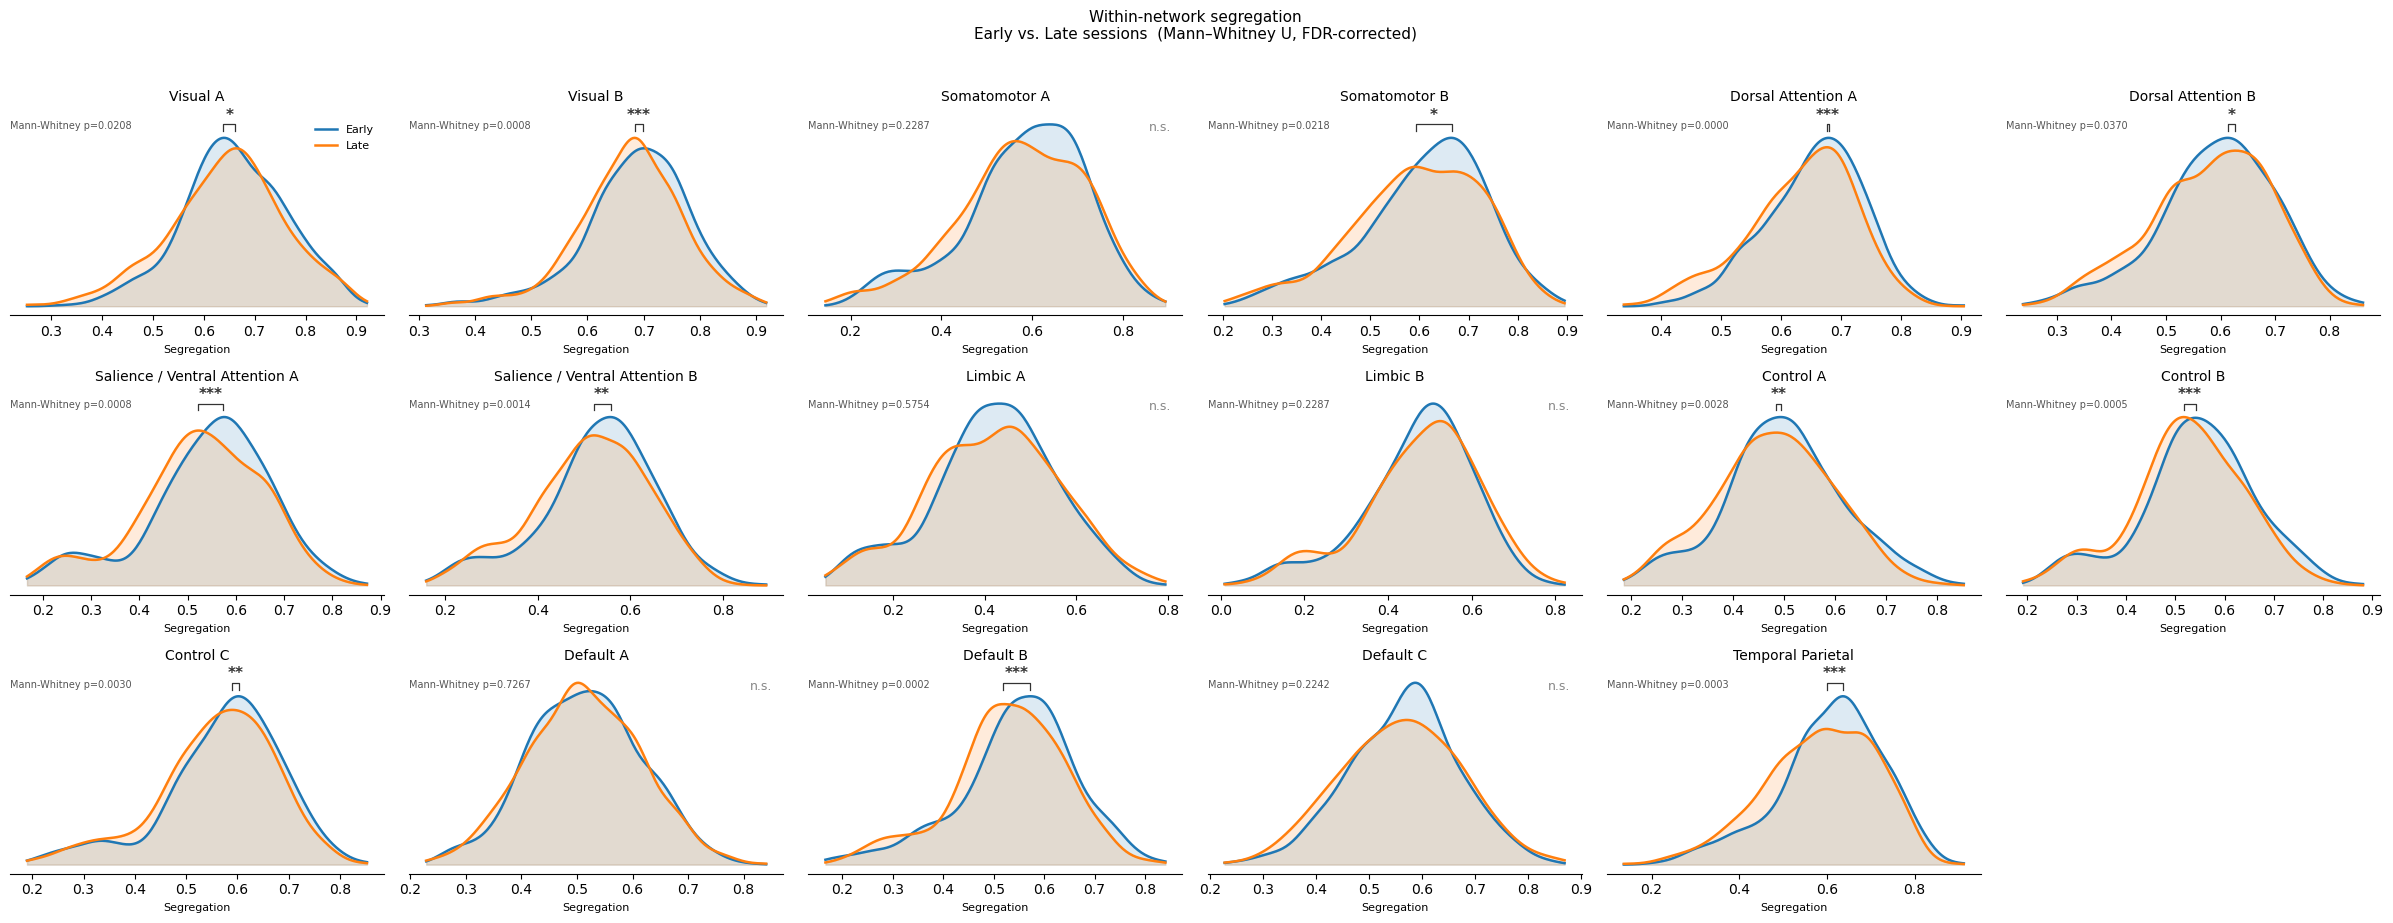

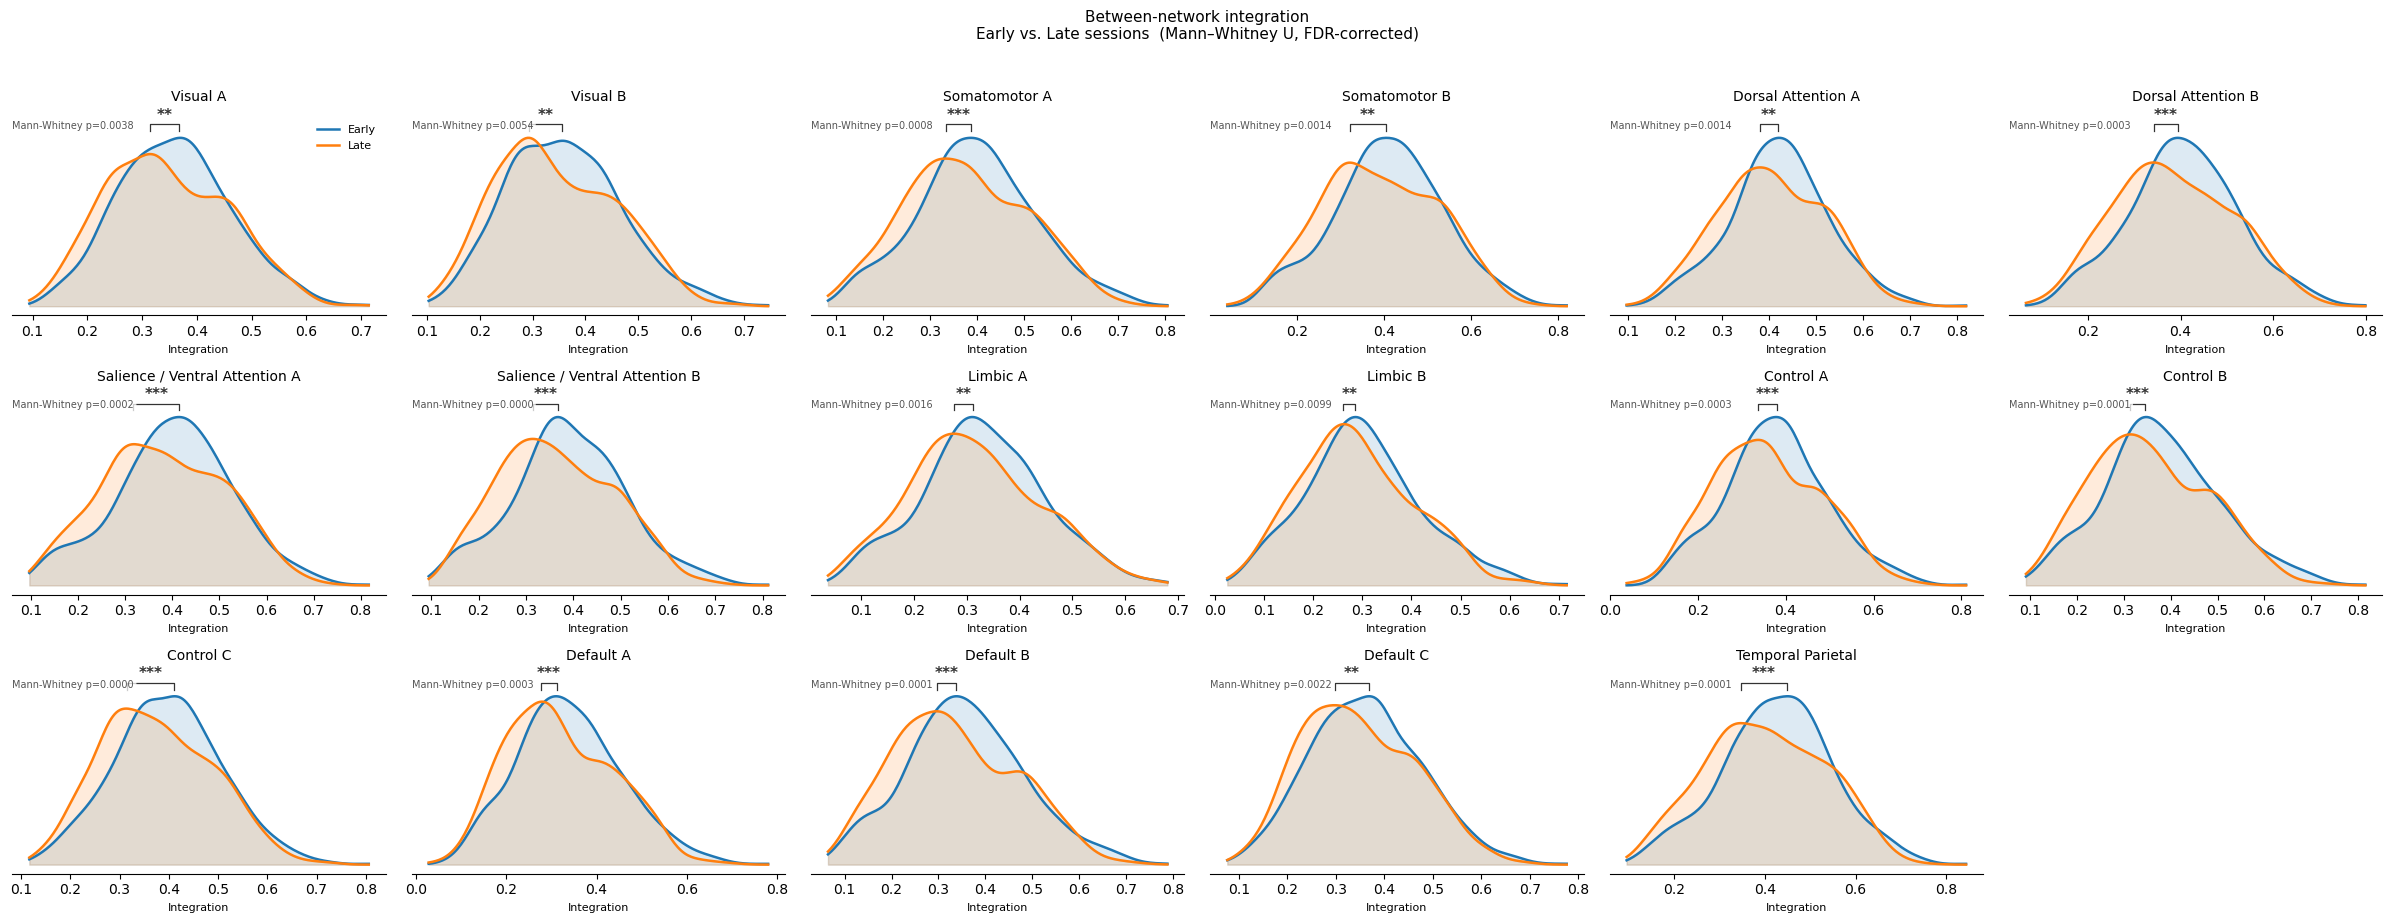

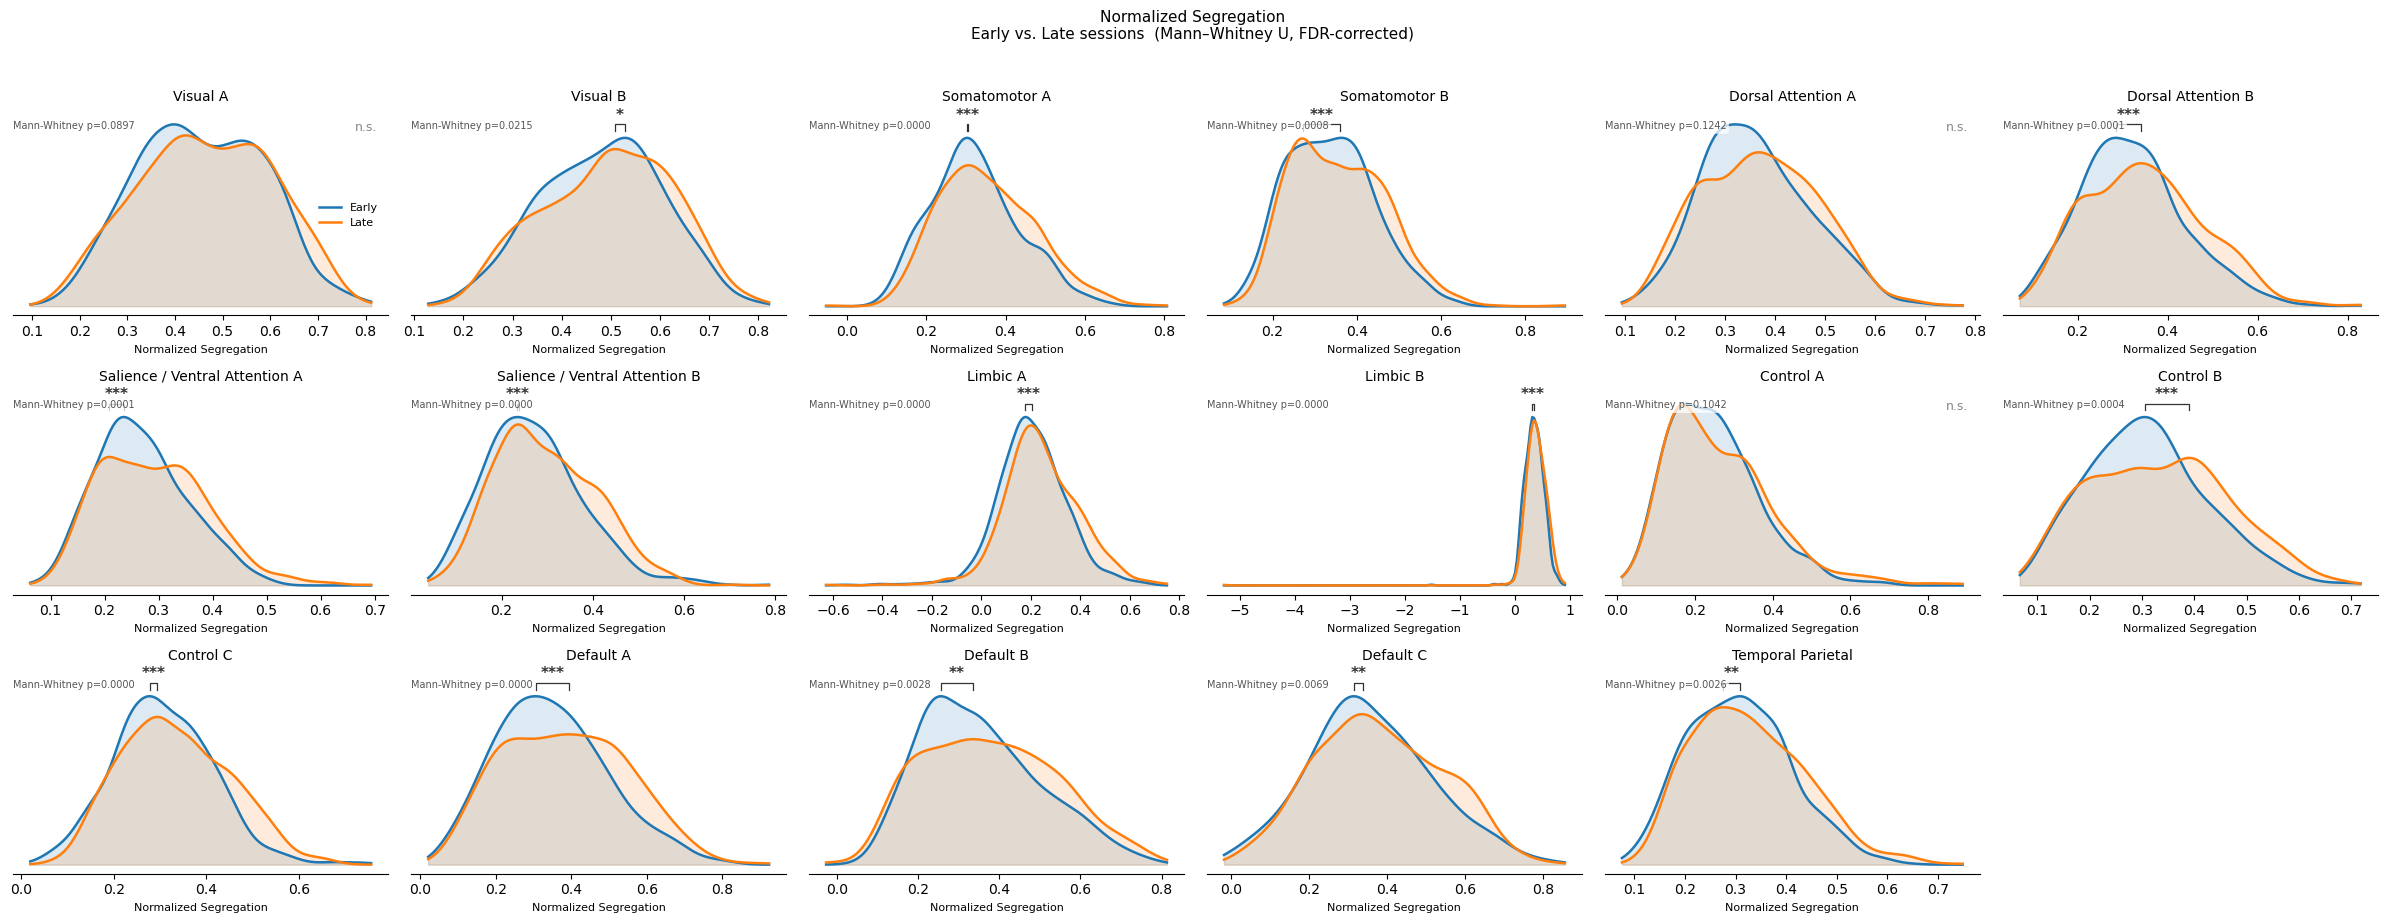

In [12]:
from scipy.stats import gaussian_kde, mannwhitneyu
from statsmodels.stats.multitest import multipletests

YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO17_NAME_MAP = {
    "VisCent": "Visual A", "VisPeri": "Visual B",
    "SomMotA": "Somatomotor A", "SomMotB": "Somatomotor B",
    "DorsAttnA": "Dorsal Attention A", "DorsAttnB": "Dorsal Attention B",
    "SalVentAttnA": "Salience / Ventral Attention A", "SalVentAttnB": "Salience / Ventral Attention B",
    "LimbicA": "Limbic A", "LimbicB": "Limbic B",
    "ContA": "Control A", "ContB": "Control B", "ContC": "Control C",
    "DefaultA": "Default A", "DefaultB": "Default B", "DefaultC": "Default C",
    "TempPar": "Temporal Parietal",
}
net_ids = [n for n in YEO17_ORDER if n in set(df_run["network"].unique())]
net_name = {net: YEO17_NAME_MAP[net] for net in net_ids}

early_sessions = ["V01", "V02", "V03", "V04", "V05", "V06", "V07"]
late_sessions  = ["V09", "V10", "V11", "V12", "V13", "V14", "V15"]

metrics = ["segregation_r", "integration_r", "normalized_segregation"]

metric_titles = {
    "segregation_r": "Within-network segregation",
    "integration_r": "Between-network integration",
    "normalized_segregation": "Normalized Segregation",
}
metric_xlabels = {
    "segregation_r": "Segregation",
    "integration_r": "Integration",
    "normalized_segregation": "Normalized Segregation",
}

def p_to_stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    else:           return "n.s."

# ── PASS 1: fit KDE on full data + collect raw MW p-values ──────────
keys     = []
raw_mw   = []
kde_data = {}

for metric in metrics:
    for net in net_ids:
        df_net       = df_run[df_run["network"] == net]
        values_early = df_net[df_net["session"].isin(early_sessions)][metric].values
        values_late  = df_net[df_net["session"].isin(late_sessions)][metric].values

        if values_early.size < 5 or values_late.size < 5:
            kde_data[(metric, net)] = None
            continue

        _, mw_p = mannwhitneyu(values_early, values_late, alternative="two-sided")

        vmin   = min(values_early.min(), values_late.min())
        vmax   = max(values_early.max(), values_late.max())
        x_grid = np.linspace(vmin, vmax, 200)

        kde_data[(metric, net)] = {
            "x_grid":     x_grid,
            "dens_early": gaussian_kde(values_early)(x_grid),
            "dens_late":  gaussian_kde(values_late)(x_grid),
            "mw_p_raw":   mw_p,
        }
        keys.append((metric, net))
        raw_mw.append(mw_p)

# ── FDR correction across all valid tests ───────────────────────────
reject, p_corrected, _, _ = multipletests(raw_mw, method="fdr_bh")

for (metric, net), p_corr, rej in zip(keys, p_corrected, reject):
    kde_data[(metric, net)]["mw_p_corr"] = p_corr
    kde_data[(metric, net)]["mw_reject"] = rej

# ── PASS 2: plot ─────────────────────────────────────────────────────
for metric in metrics:
    n_cols = 6
    n_rows = int(np.ceil(len(net_ids) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    for i, net in enumerate(net_ids):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        d  = kde_data[(metric, net)]

        if d is None:
            ax.set_title(f"{net_name[net]} (too few samples)")
            ax.axis("off")
            continue

        ax.plot(d["x_grid"], d["dens_early"], color="C0", lw=1.8, label="Early")
        ax.plot(d["x_grid"], d["dens_late"],  color="C1", lw=1.8, label="Late")
        ax.fill_between(d["x_grid"], d["dens_early"], alpha=0.15, color="C0")
        ax.fill_between(d["x_grid"], d["dens_late"],  alpha=0.15, color="C1")

        mw_stars = p_to_stars(d["mw_p_corr"])
        y_top    = max(d["dens_early"].max(), d["dens_late"].max())

        if mw_stars != "n.s.":
            x_lo = d["x_grid"][np.argmax(d["dens_early"])]
            x_hi = d["x_grid"][np.argmax(d["dens_late"])]
            x_lo, x_hi = sorted([x_lo, x_hi])
            y_bar  = y_top * 1.08
            y_tick = y_top * 1.04
            ax.plot([x_lo, x_lo, x_hi, x_hi],
                    [y_tick, y_bar, y_bar, y_tick],
                    lw=0.9, color="#333")
            ax.text((x_lo + x_hi) / 2, y_bar * 1.01, mw_stars,
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color="#333")
        else:
            ax.text(0.97, 0.97, "n.s.",
                    transform=ax.transAxes,
                    ha="right", va="top",
                    fontsize=9, color="#888")

        ax.text(0, 0.97,
                f"Mann-Whitney p={d['mw_p_corr']:.4f}",
                transform=ax.transAxes,
                ha="left", va="top", fontsize=7, color="#555",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", alpha=0.75, edgecolor="none"))

        ax.set_title(net_name[net], fontsize=10, pad=10)
        ax.set_xlabel(metric_xlabels.get(metric, metric), fontsize=8)
        ax.yaxis.set_visible(False)
        ax.spines[["top", "left", "right"]].set_visible(False)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, frameon=False)

    for j in range(i + 1, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(
        f"{metric_titles.get(metric, metric)}\n"
        "Early vs. Late sessions  (Mann–Whitney U, FDR-corrected)",
        y=1.02, fontsize=11
    )
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"kde_{metric}_early_vs_late_yeo17.png"), bbox_inches="tight", dpi=300)
    plt.show()

c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the pa

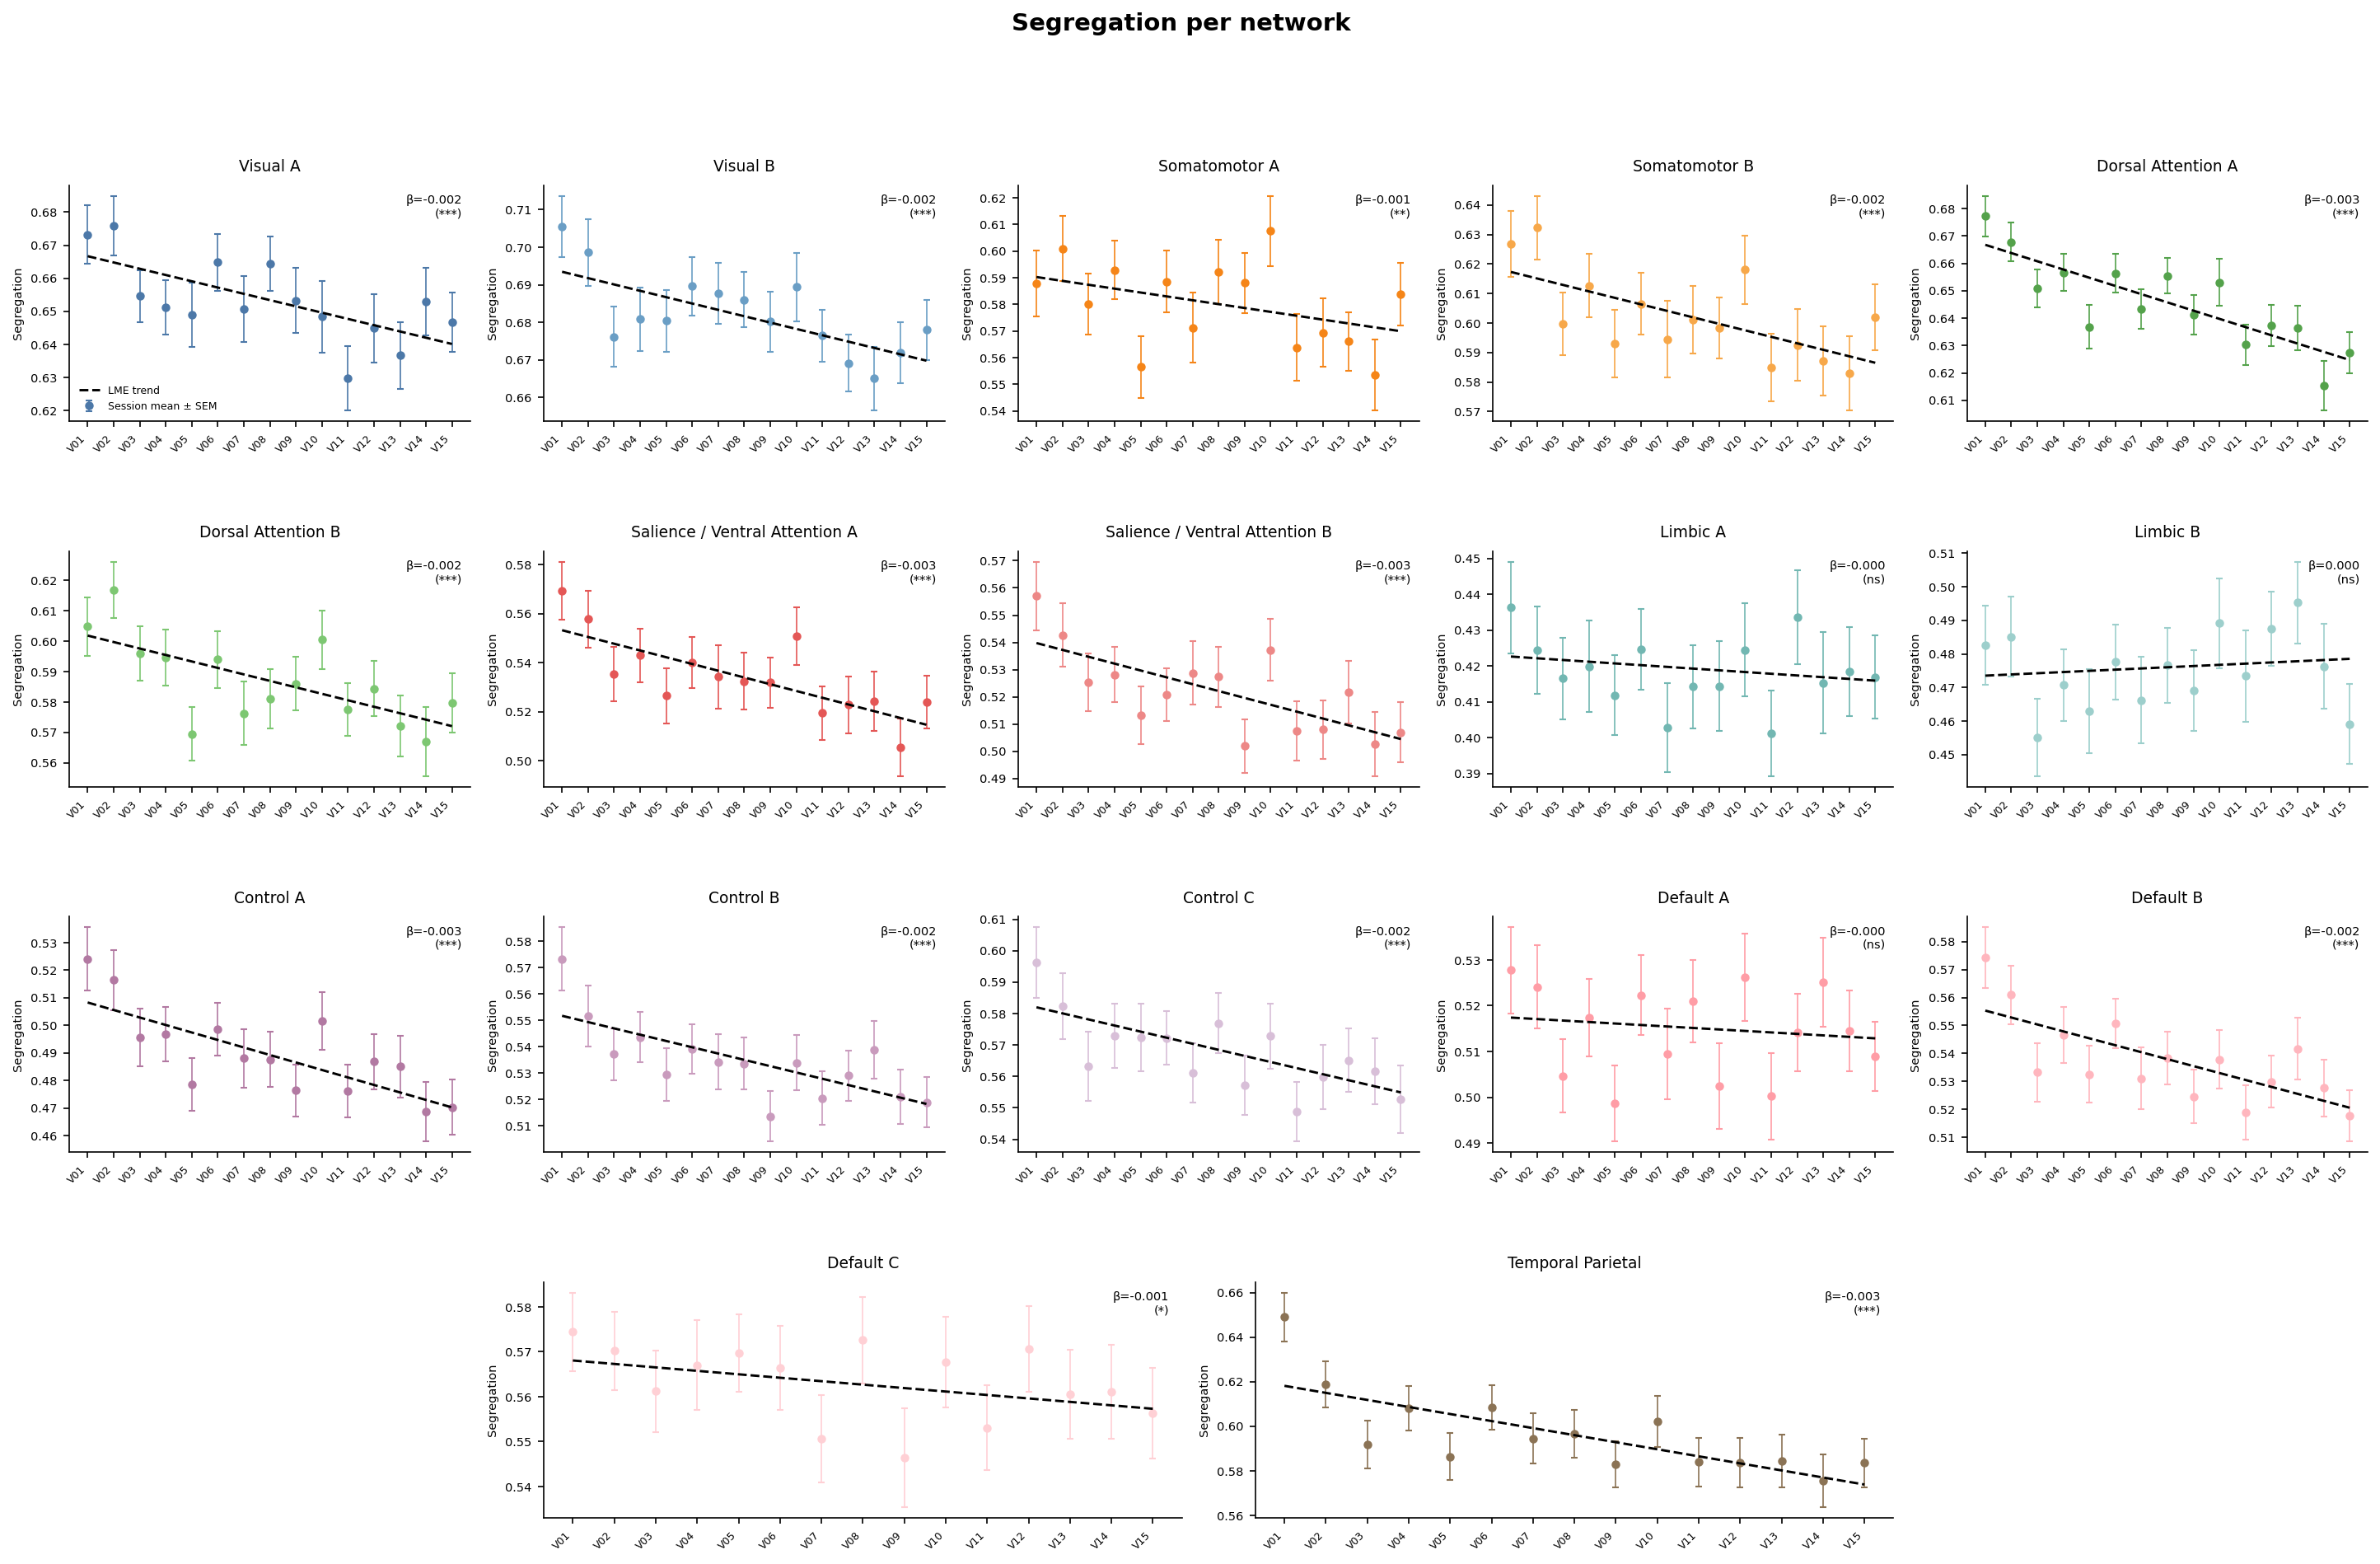

c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarni

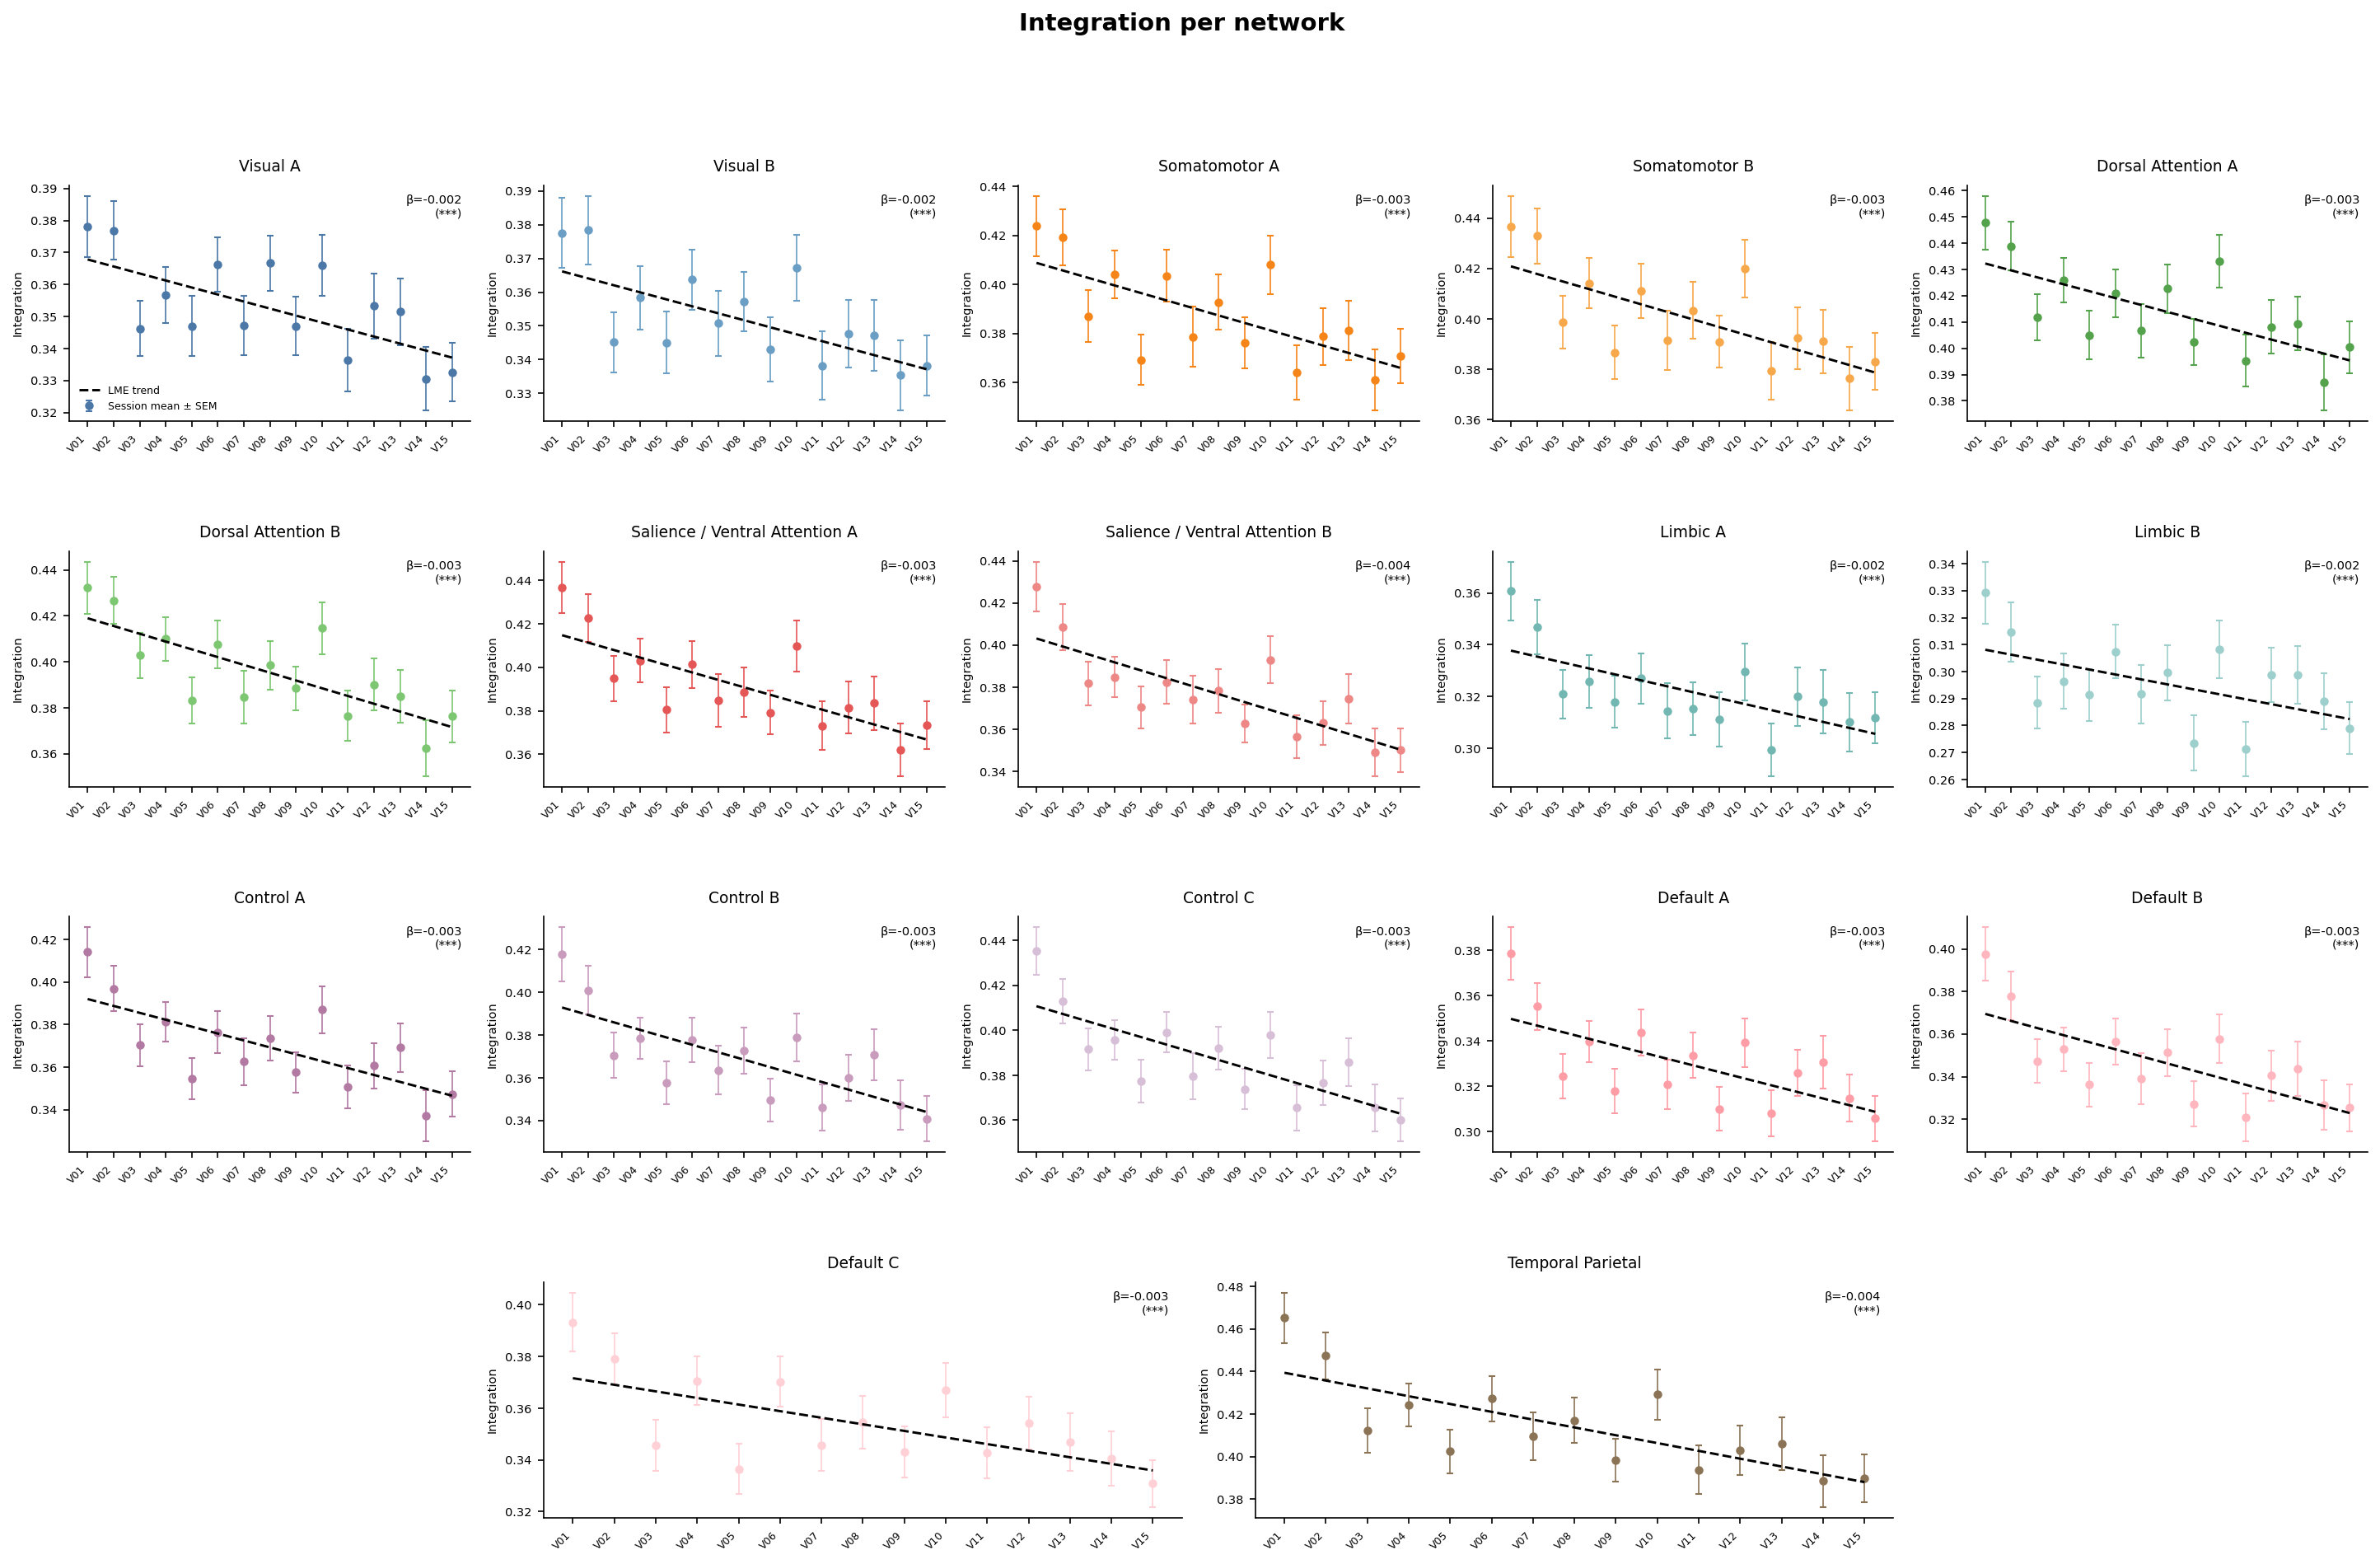

c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\tesni\miniconda3\envs\ada\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarni

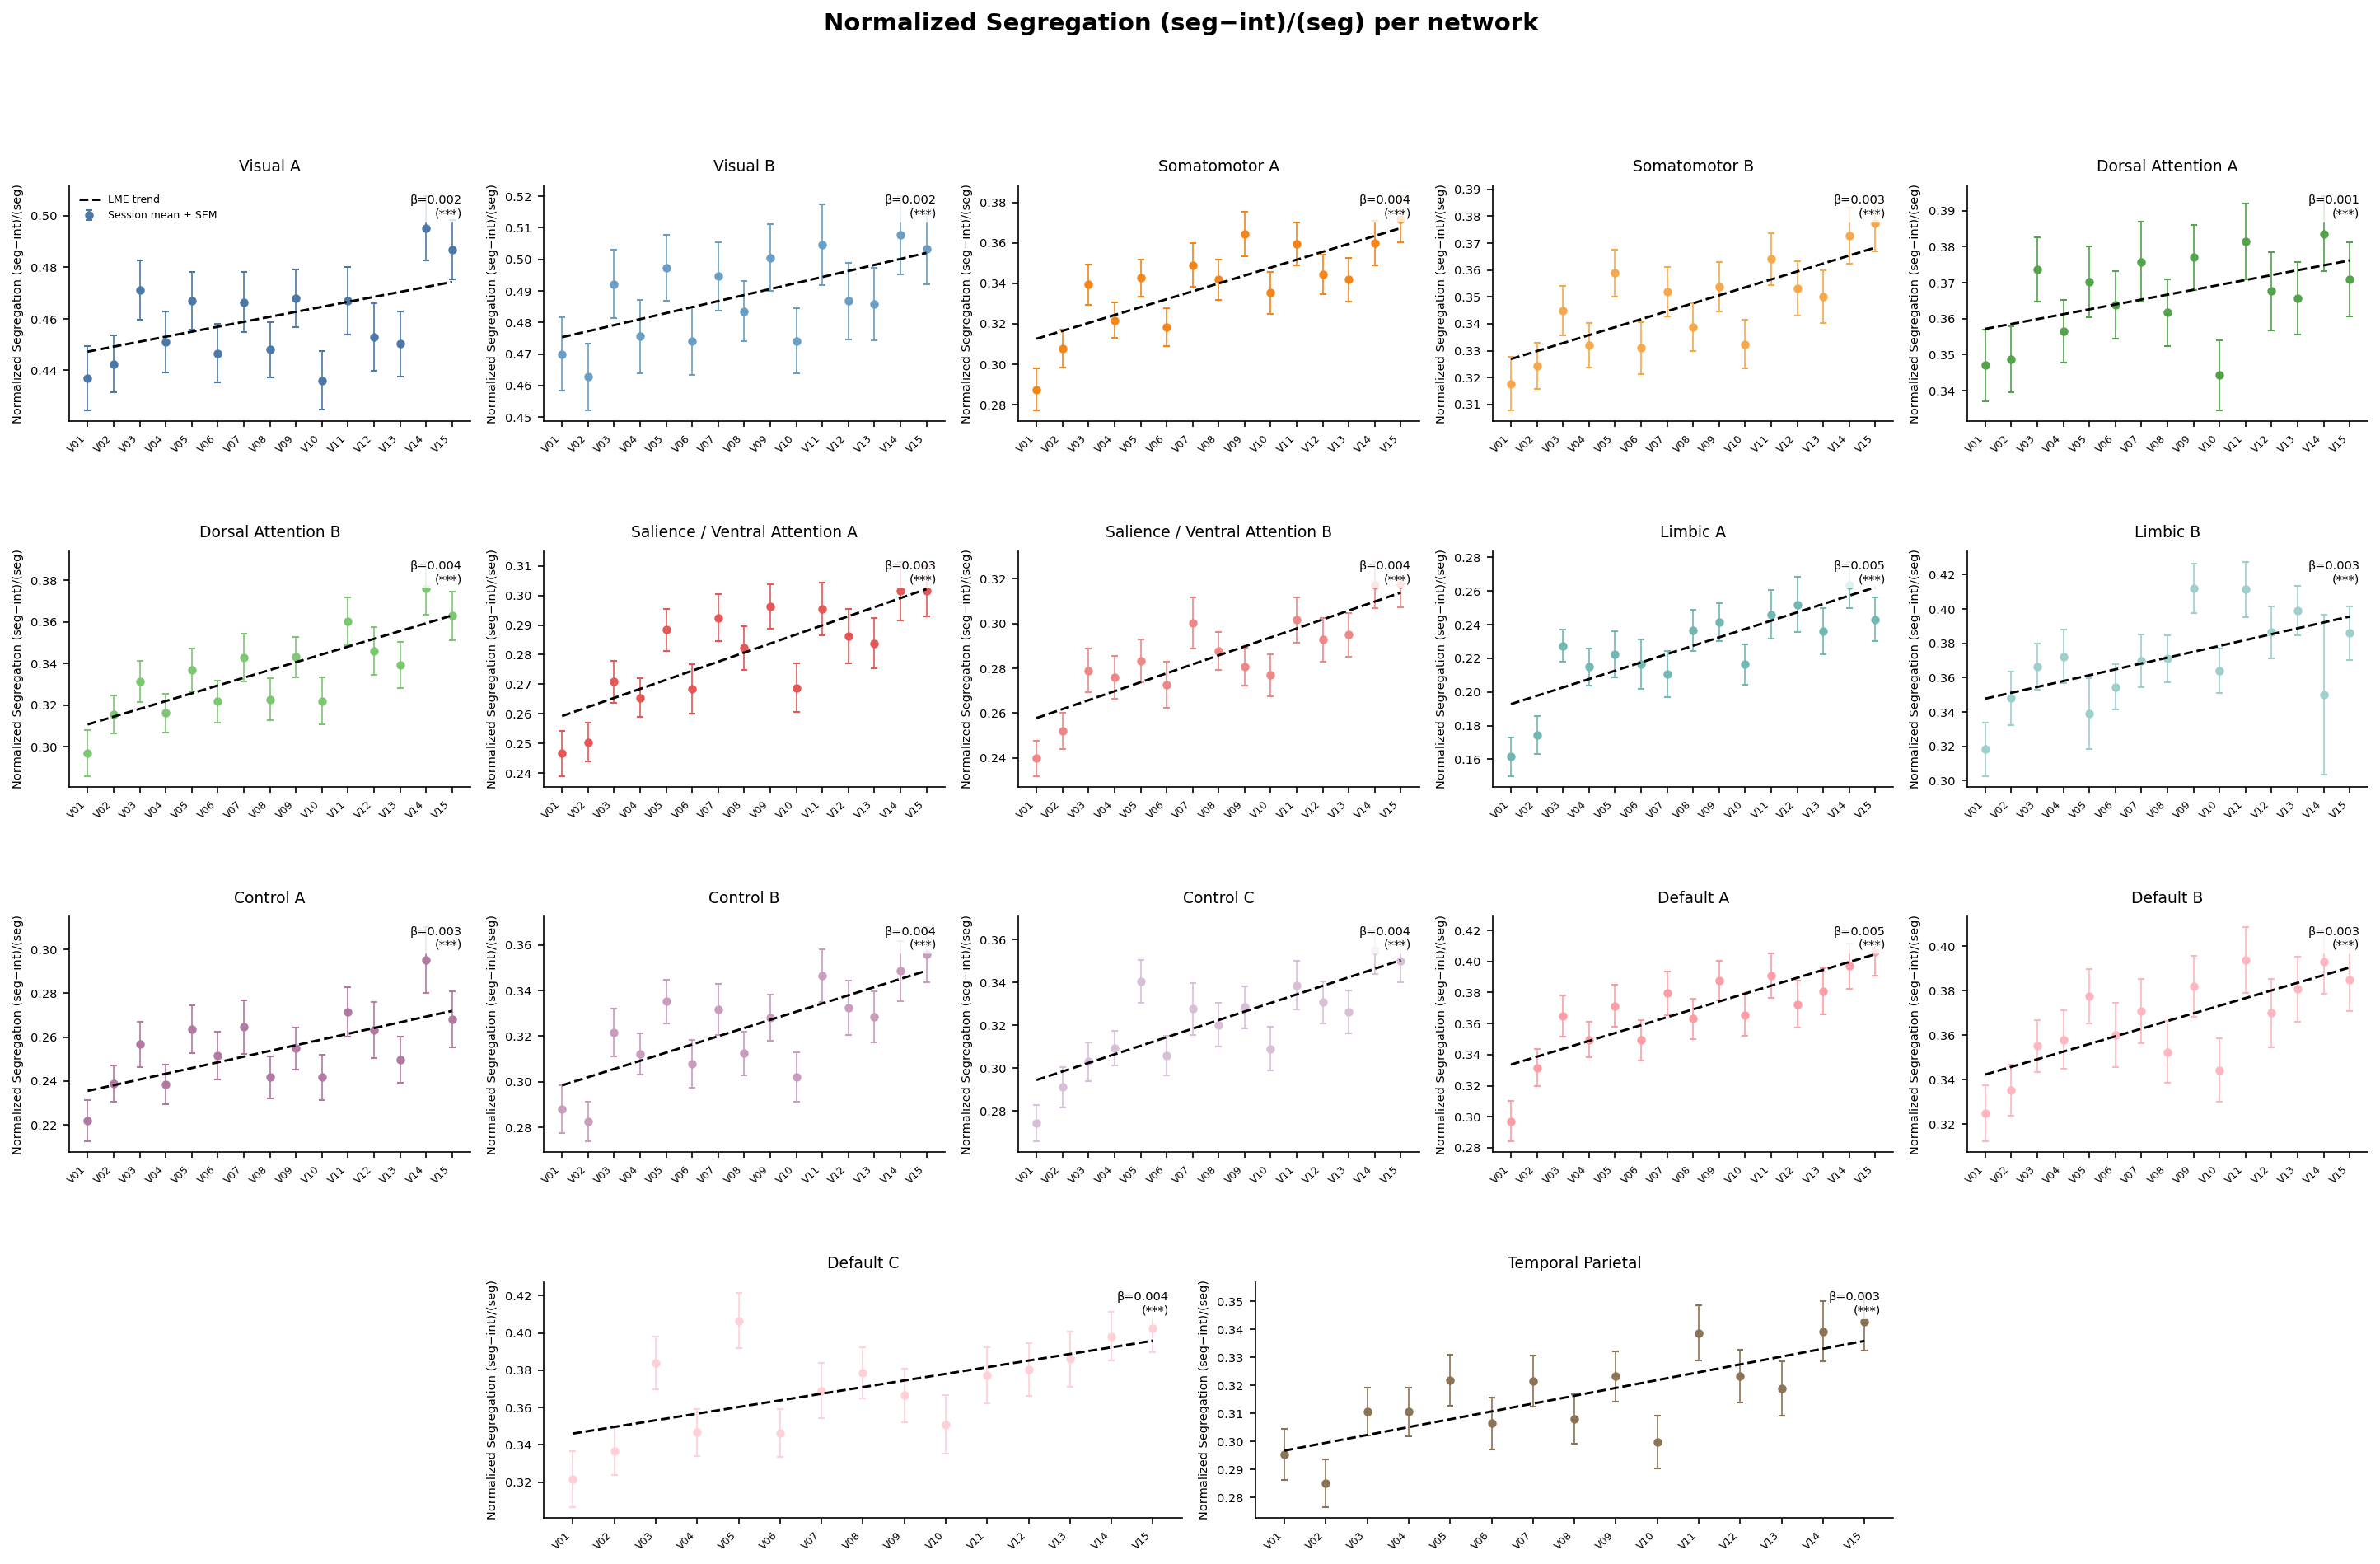

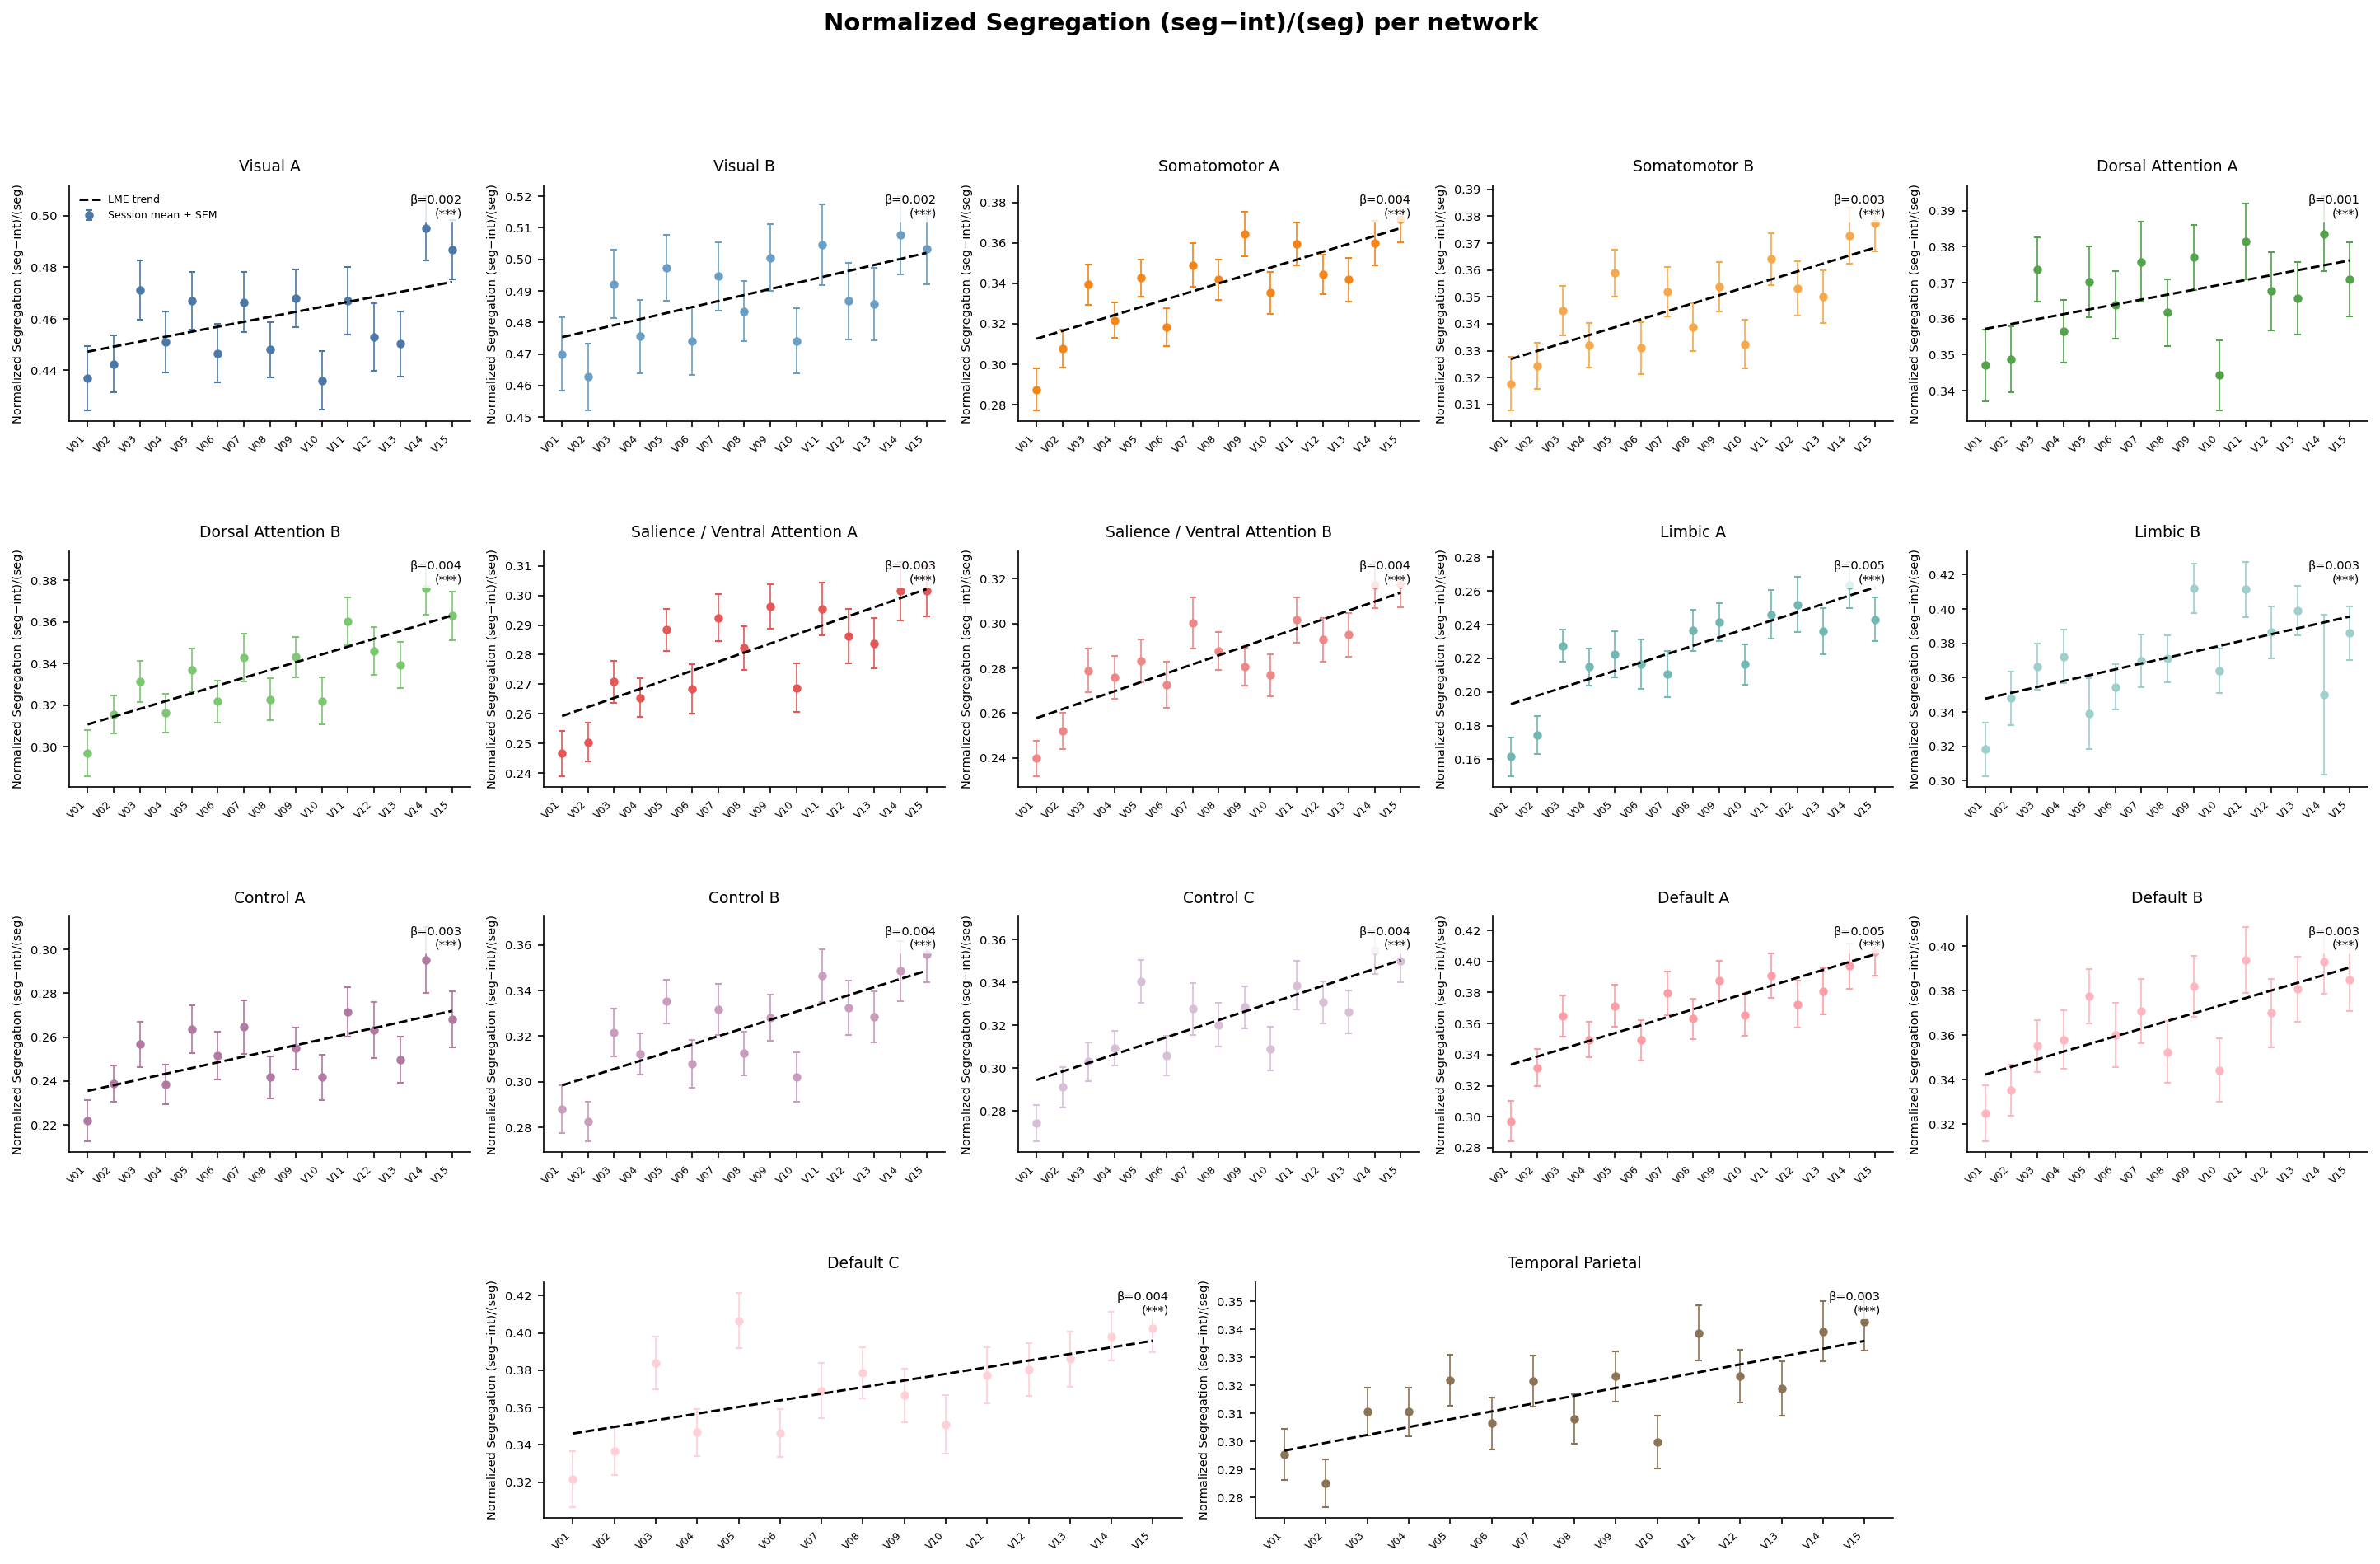

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
METRICS_PATH = "../../../Results/Tessnim/all_subjects_yeo17_metrics.csv"

YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO17_NAME_MAP = {
    "VisCent": "Visual A", "VisPeri": "Visual B",
    "SomMotA": "Somatomotor A", "SomMotB": "Somatomotor B",
    "DorsAttnA": "Dorsal Attention A", "DorsAttnB": "Dorsal Attention B",
    "SalVentAttnA": "Salience / Ventral Attention A", "SalVentAttnB": "Salience / Ventral Attention B",
    "LimbicA": "Limbic A", "LimbicB": "Limbic B",
    "ContA": "Control A", "ContB": "Control B", "ContC": "Control C",
    "DefaultA": "Default A", "DefaultB": "Default B", "DefaultC": "Default C",
    "TempPar": "Temporal Parietal",
}
YEO17_COLOR_MAP = {
    "VisCent": "#4C78A8", "VisPeri": "#6A9EC5",
    "SomMotA": "#F58518", "SomMotB": "#F7A84A",
    "DorsAttnA": "#54A24B", "DorsAttnB": "#7DC772",
    "SalVentAttnA": "#E45756", "SalVentAttnB": "#ED8887",
    "LimbicA": "#72B7B2", "LimbicB": "#9DCFCC",
    "ContA": "#B279A2", "ContB": "#C99BBD", "ContC": "#D8BFD8",
    "DefaultA": "#FF9DA6", "DefaultB": "#FFB6BE", "DefaultC": "#FFD0D5",
    "TempPar": "#8B7355",
}

# ── Load & prepare data ───────────────────────────────────────────────────────
df_export = pd.read_csv(METRICS_PATH)

df_r200 = (
    df_export
    .groupby(["subject", "session", "run", "condition", "network"], as_index=False)
    .agg(segregation=("segregation", "mean"), integration=("integration", "mean"))
)
df_r200["session_num"] = df_r200["session"].str.extract(r"V(\d+)", expand=False).astype(int)
df_r200["subject"]     = df_r200["subject"].astype("category")
df_r200["normalized_segregation"] = (df_r200["segregation"] - df_r200["integration"]) / (df_r200["segregation"])

net_ids   = [n for n in YEO17_ORDER if n in set(df_r200["network"].unique())]
net_name  = {net: YEO17_NAME_MAP[net] for net in net_ids}
net_color = {net: YEO17_COLOR_MAP[net] for net in net_ids}

# ── Helpers ───────────────────────────────────────────────────────────────────
def stars_from_p(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def fit_lmm_per_network(df, metric, condition_filter=None, correction="fdr_bh"):
    work = df.copy()
    if condition_filter is not None:
        work = work[work["condition"] == condition_filter].copy()

    results = []
    for net in net_ids:
        df_net = work[work["network"] == net].copy()
        try:
            res = smf.mixedlm(f"{metric} ~ session_num", df_net,
                               groups=df_net["subject"]).fit(method="lbfgs", disp=False)
            results.append({
                "network":       net,
                "beta_session":  float(res.params["session_num"]),
                "se_session":    float(res.bse["session_num"]),
                "p_session":     float(res.pvalues["session_num"]),
            })
        except Exception:
            results.append({"network": net, "beta_session": np.nan,
                            "se_session": np.nan, "p_session": np.nan})

    out = pd.DataFrame(results).sort_values("network").reset_index(drop=True)
    valid = out["p_session"].notna()
    out.loc[valid, "p_corr"] = multipletests(
        out.loc[valid, "p_session"].values, method=correction)[1]
    out.loc[~valid, "p_corr"] = np.nan
    return out


def make_yeo17_axes(figsize=(24, 14), dpi=150):
    """4-row grid: 5 + 5 + 5 + 2 centred, matching 17 networks."""
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = fig.add_gridspec(4, 10, wspace=0.45, hspace=0.55)

    axes = []
    # row 0: nets 1-5
    for c in range(5):
        axes.append(fig.add_subplot(gs[0, c*2 : c*2+2]))
    # row 1: nets 6-10
    for c in range(5):
        axes.append(fig.add_subplot(gs[1, c*2 : c*2+2]))
    # row 2: nets 11-15
    for c in range(5):
        axes.append(fig.add_subplot(gs[2, c*2 : c*2+2]))
    # row 3: nets 16-17, centred over cols 3-6
    axes.append(fig.add_subplot(gs[3, 2:5]))
    axes.append(fig.add_subplot(gs[3, 5:8]))

    return fig, axes


# ── Main plot function ────────────────────────────────────────────────────────
def plot_trend_per_network_yeo17(
    df_long,
    stats_df,
    metric="segregation",
    condition_filter=None,
    figsize=(24, 14),
    dpi=150,
    save_path=None,
):
    metric_labels = {
        "segregation": "Segregation",
        "integration": "Integration",
        "normalized_segregation": "Normalized Segregation (seg−int)/(seg)",
    }

    work_df = df_long.copy()
    if condition_filter is not None:
        work_df = work_df[work_df["condition"] == condition_filter].copy()
    cond_str = f" [{condition_filter}]" if condition_filter else ""

    all_sessions = sorted(work_df["session"].dropna().unique(),
                          key=lambda s: int(str(s).replace("V", "")))
    sess_to_x = {s: i for i, s in enumerate(all_sessions)}

    fig, axes_list = make_yeo17_axes(figsize=figsize, dpi=dpi)
    fig.suptitle(
        f"{metric_labels.get(metric, metric)} per network",
        fontsize=14, fontweight="bold", y=0.98
    )

    for ax_i, (net, ax) in enumerate(zip(net_ids, axes_list)):
        net_df = work_df[work_df["network"] == net].copy()

        if net_df.empty:
            ax.set_title(net_name[net])
            ax.axis("off")
            continue

        # session means ± SEM
        sess_stats = (
            net_df.groupby("session")[metric]
            .agg(mean="mean", sem=lambda x: x.sem())
            .reindex(all_sessions)
            .reset_index()
        )
        sess_stats["x"] = sess_stats["session"].map(sess_to_x)

        # LME trend line
        try:
            lme = smf.mixedlm(f"{metric} ~ session_num", data=net_df,
                               groups=net_df["subject"]).fit(reml=True, disp=False)
            x_num  = np.linspace(net_df["session_num"].min(),
                                  net_df["session_num"].max(), 200)
            y_pred = lme.params["Intercept"] + lme.params["session_num"] * x_num
            x_num_min, x_num_max = net_df["session_num"].min(), net_df["session_num"].max()
            x_axis = (x_num - x_num_min) / (x_num_max - x_num_min) * (len(all_sessions) - 1)
            ax.plot(x_axis, y_pred, color="black", linestyle="--",
                    linewidth=1.4, label="LME trend", zorder=3)
        except Exception:
            pass

        # observed means + SEM
        ax.errorbar(
            sess_stats["x"], sess_stats["mean"], yerr=sess_stats["sem"],
            fmt="o", color=net_color[net],
            markersize=4, linewidth=0.8, elinewidth=0.8, capsize=2,
            label="Session mean ± SEM", zorder=2,
        )

        ax.set_xticks(range(len(all_sessions)))
        ax.set_xticklabels(all_sessions, rotation=45, ha="right", fontsize=6)
        ax.set_ylabel(metric_labels[metric], fontsize=7)
        ax.set_title(net_name[net], fontsize=9, pad=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis="y", labelsize=7)

        if ax_i == 0:
            ax.legend(fontsize=6, frameon=False)

        # stats annotation
        stat_row = stats_df.loc[stats_df["network"] == net]
        if not stat_row.empty and pd.notna(stat_row["p_corr"].iloc[0]):
            beta   = float(stat_row["beta_session"].iloc[0])
            p_corr = float(stat_row["p_corr"].iloc[0])
            stars  = stars_from_p(p_corr)
            ax.text(
                0.98, 0.96,
                f"β={beta:.3f}\n({stars})",
                transform=ax.transAxes,
                ha="right", va="top", fontsize=7,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8),
            )

    # hide any leftover axes (shouldn't be any for 17, but just in case)
    for ax in axes_list[len(net_ids):]:
        ax.set_visible(False)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig


# ── Run ───────────────────────────────────────────────────────────────────────
seg_stats = fit_lmm_per_network(df_r200, metric="segregation")
int_stats = fit_lmm_per_network(df_r200, metric="integration")
norm_seg_stats = fit_lmm_per_network(df_r200, metric="normalized_segregation")
plot_trend_per_network_yeo17(
    df_long=df_r200, stats_df=seg_stats, metric="segregation",
    save_path=os.path.join(FIGURES_DIR, "segregation_trend_per_network_yeo17.png"),
)

plot_trend_per_network_yeo17(
    df_long=df_r200, stats_df=int_stats, metric="integration",
    save_path=os.path.join(FIGURES_DIR, "integration_trend_per_network_yeo17.png"),
)

plot_trend_per_network_yeo17(
    df_long=df_r200, stats_df=norm_seg_stats, metric="normalized_segregation",
    save_path=os.path.join(FIGURES_DIR, "normalized_segregation_trend_per_network_yeo17.png"),
)

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\1440586378.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_significance_KS.png


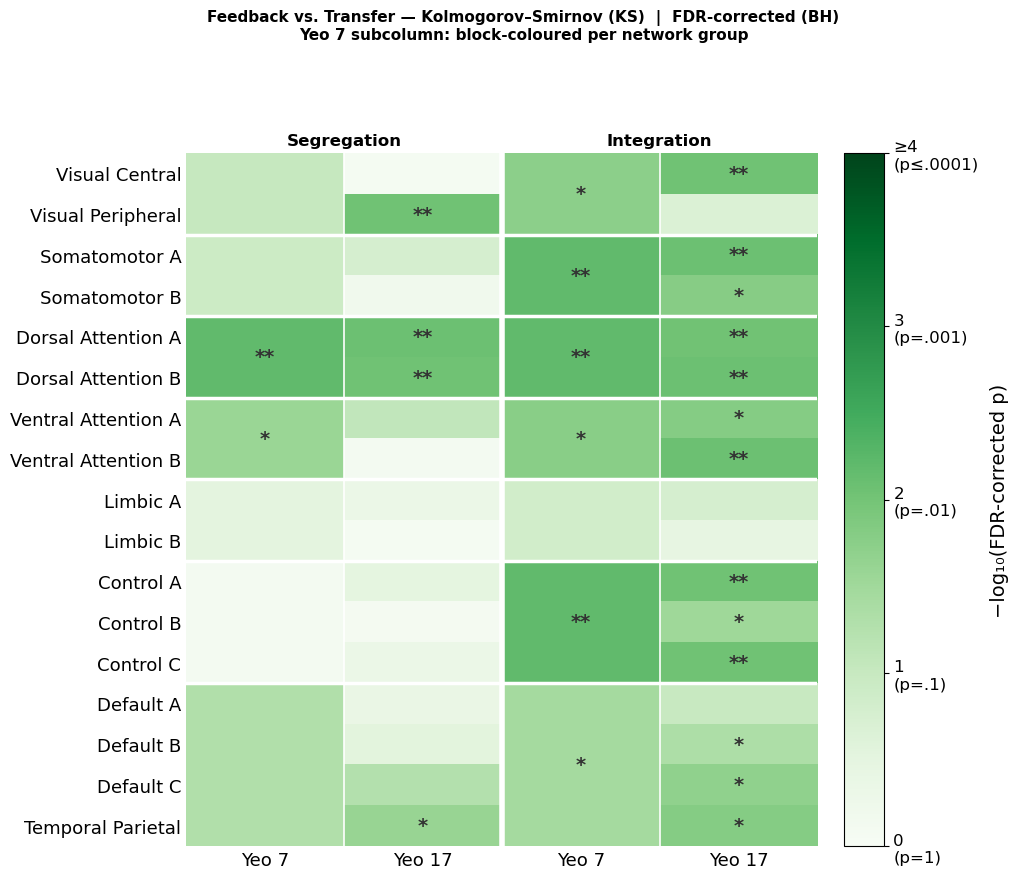

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\1440586378.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_significance_MW.png


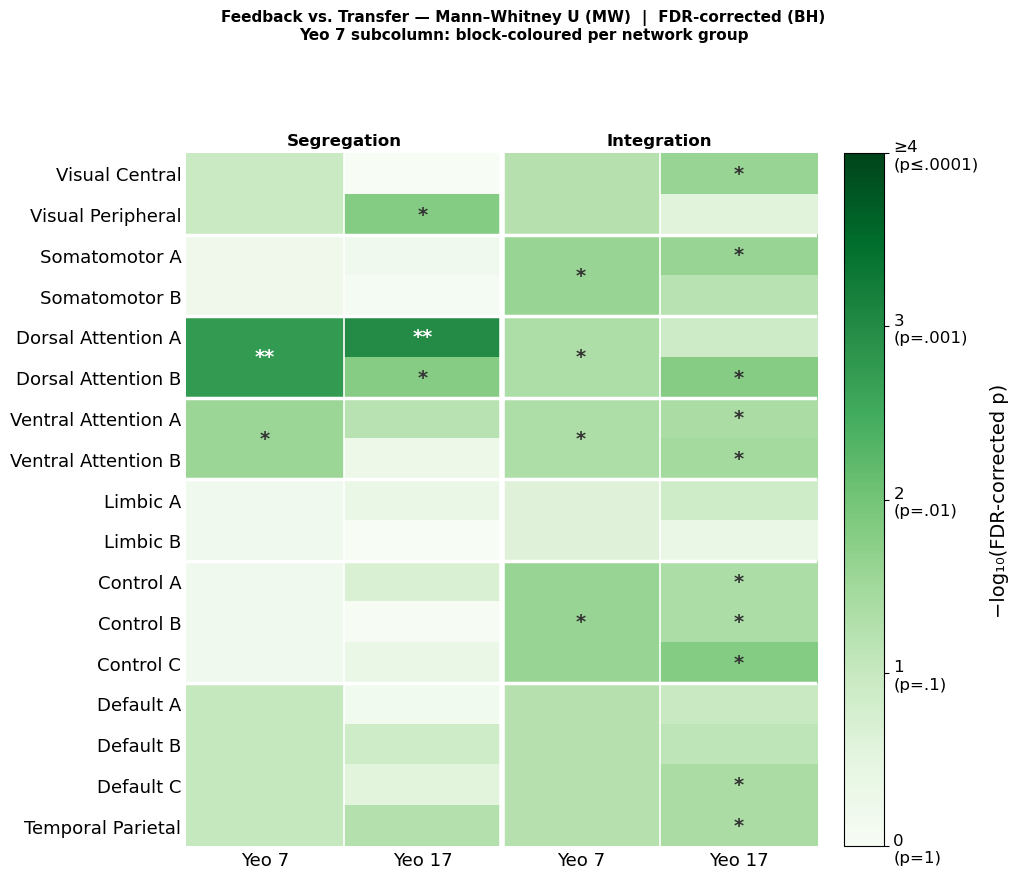

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import ks_2samp, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── Network definitions ───────────────────────────────────────────────────────
YEO7_IDS   = [1, 2, 3, 4, 5, 6, 7]
YEO7_NAMES = {
    1: "Visual",           2: "Somatomotor",
    3: "Dorsal Attention", 4: "Ventral Attention",
    5: "Limbic",           6: "Frontoparietal",
    7: "Default",
}

_YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
_YEO17_NAME_MAP = {
    "VisCent":      "Visual Central",             "VisPeri":      "Visual Peripheral",
    "SomMotA":      "Somatomotor A",              "SomMotB":      "Somatomotor B",
    "DorsAttnA":    "Dorsal Attention A",          "DorsAttnB":    "Dorsal Attention B",
    "SalVentAttnA": "Ventral Attention A",          "SalVentAttnB": "Ventral Attention B",
    "LimbicA":      "Limbic A",                   "LimbicB":      "Limbic B",
    "ContA":        "Control A",                  "ContB":        "Control B",
    "ContC":        "Control C",                  "DefaultA":     "Default A",
    "DefaultB":     "Default B",                  "DefaultC":     "Default C",
    "TempPar":      "Temporal Parietal",
}


YEO7_GROUP_SIZES = [2, 2, 2, 2, 2, 3, 4]
_starts          = [0] + list(np.cumsum(YEO7_GROUP_SIZES))
YEO17_SEPARATORS = np.cumsum(YEO7_GROUP_SIZES)[:-1] - 0.5

# ── Load & aggregate ──────────────────────────────────────────────────────────
CSV7  = "../../../Results/Tessnim/all_subjects_yeo7_metrics.csv"
CSV17 = "../../../Results/Tessnim/all_subjects_yeo17_metrics.csv"

def _load_and_agg(path):
    df = pd.read_csv(path)
    # CSV already stores r-space values (tanh applied during computation)
    df["segregation_r"] = df["segregation"]
    df["integration_r"] = df["integration"]
    return df.groupby(
        ["subject", "session", "run", "condition", "network"], as_index=False
    )[["segregation_r", "integration_r"]].mean()

df7_run  = _load_and_agg(CSV7)
df17_run = _load_and_agg(CSV17)

# ── Compute FDR-corrected KS + MW ─────────────────────────────────────────────
def _compute_stats(df_run, net_ids):
    rows = []
    for metric in ["segregation_r", "integration_r"]:
        for net in net_ids:
            s  = df_run[df_run["network"] == net]
            fb = s[s["condition"] == "Feedback"][metric].values
            tr = s[s["condition"] == "Transfer"][metric].values
            if fb.size < 5 or tr.size < 5:
                rows.append({"net": net, "metric": metric, "ks_p": np.nan, "mw_p": np.nan})
                continue
            _, ks_p = ks_2samp(fb, tr, alternative="two-sided")
            _, mw_p = mannwhitneyu(fb, tr, alternative="two-sided")
            rows.append({"net": net, "metric": metric, "ks_p": ks_p, "mw_p": mw_p})
    out = pd.DataFrame(rows)
    for col in ["ks_p", "mw_p"]:
        valid = out[col].notna()
        corr  = np.full(len(out), np.nan)
        if valid.any():
            corr[valid] = multipletests(out.loc[valid, col], method="fdr_bh")[1]
        out[f"{col}_corr"] = corr
    return out

stats7  = _compute_stats(df7_run,  YEO7_IDS)
stats17 = _compute_stats(df17_run, _YEO17_ORDER)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _pval_to_neg_log(p):
    return np.clip(-np.log10(max(p, 1e-10)), 0, 4) if pd.notna(p) else np.nan

def _star(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

# ── Build matrix + two separate star lists ────────────────────────────────────
# Column layout:
#   col 0 = Segregation / Yeo-7   (block-expanded)
#   col 1 = Segregation / Yeo-17
#   col 2 = Integration / Yeo-7   (block-expanded)
#   col 3 = Integration / Yeo-17
#
# Stars are kept in two separate lists so Yeo-7 stars can use float y-positions
# (true vertical midpoint of each block) while Yeo-17 stars use integer rows.

def _build_combined_matrix(test_col):
    mat = np.full((17, 4), np.nan)

    # stars_yeo7  : list of (y_float, col, star_str)  — float midpoint of block
    # stars_yeo17 : list of (y_int,   col, star_str)  — integer row index
    stars_yeo7  = []
    stars_yeo17 = []

    # ── Yeo-7 columns (0 = Seg, 2 = Int) ─────────────────────────────────────
    for gi, net7 in enumerate(YEO7_IDS):
        row_start = _starts[gi]
        row_end   = _starts[gi + 1]
        # True float midpoint of the block — works correctly for every group size
        y_mid = (row_start + row_end - 1) / 2.0

        for mi, metric in enumerate(["segregation_r", "integration_r"]):
            col = mi * 2                        # 0 for Seg, 2 for Int
            row = stats7[(stats7["net"] == net7) & (stats7["metric"] == metric)]
            if row.empty:
                continue
            p = row[test_col].iloc[0]
            mat[row_start:row_end, col] = _pval_to_neg_log(p)
            s = _star(p)
            if s:
                stars_yeo7.append((y_mid, col, s, _pval_to_neg_log(p)))

    # ── Yeo-17 columns (1 = Seg, 3 = Int) ────────────────────────────────────
    for ri, net17 in enumerate(_YEO17_ORDER):
        for mi, metric in enumerate(["segregation_r", "integration_r"]):
            col = mi * 2 + 1                    # 1 for Seg, 3 for Int
            row = stats17[(stats17["net"] == net17) & (stats17["metric"] == metric)]
            if row.empty:
                continue
            p = row[test_col].iloc[0]
            v = _pval_to_neg_log(p)
            mat[ri, col] = v
            s = _star(p)
            if s:
                stars_yeo17.append((ri, col, s, v))

    return mat, stars_yeo7, stars_yeo17

# ── Plot ──────────────────────────────────────────────────────────────────────
CMAP       = plt.cm.Greens
NORM       = mcolors.Normalize(vmin=0, vmax=4)
SUB_LABELS = ["Yeo 7", "Yeo 17", "Yeo 7", "Yeo 17"]

def _make_figure(test_col, test_label, out_fname):
    mat, stars_yeo7, stars_yeo17 = _build_combined_matrix(test_col)

    fig = plt.figure(figsize=(9, 9))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 0.25], wspace=0.08, figure=fig)
    ax  = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.imshow(mat, cmap=CMAP, norm=NORM, aspect="auto")

    # Yeo-7 stars — placed at the true float midpoint of each block
    for y, c, s, v in stars_yeo7:
        color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax.text(c, y, s, ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

    # Yeo-17 stars — integer row positions
    for r, c, s, v in stars_yeo17:
        color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax.text(c, r, s, ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)

    # Horizontal separators
    for b in YEO17_SEPARATORS:
        ax.axhline(b, color="white", lw=2.5, zorder=5)

    # Vertical dividers
    ax.axvline(0.5, color="white", lw=1.2, zorder=5)   # Seg:  Yeo7 | Yeo17
    ax.axvline(1.5, color="white", lw=4.0, zorder=5)   # ===  Seg  |  Int  ===
    ax.axvline(2.5, color="white", lw=1.2, zorder=5)   # Int:  Yeo7 | Yeo17

    # Bottom x-axis: sub-column labels
    ax.set_xticks(range(4))
    ax.set_xticklabels(SUB_LABELS, fontsize=13)
    ax.tick_params(axis="x", length=0)

    # Y-axis: Yeo-17 network names
    ax.set_yticks(range(17))
    ax.set_yticklabels([_YEO17_NAME_MAP[n] for n in _YEO17_ORDER], fontsize=13)
    ax.tick_params(axis="y", length=0)
    ax.spines[:].set_visible(False)

    # Top x-axis: main metric group labels
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([0.5, 2.5])
    ax2.set_xticklabels(["Segregation", "Integration"],
                        fontsize=12, fontweight="bold")
    ax2.tick_params(length=0)
    ax2.spines[:].set_visible(False)

    # Colourbar
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), cax=cax)
    cb.set_label("−log₁₀(FDR-corrected p)", fontsize=14, labelpad=8)
    cb.set_ticks([0, 1, 2, 3, 4])
    cb.set_ticklabels(
        ["0\n(p=1)", "1\n(p=.1)", "2\n(p=.01)", "3\n(p=.001)", "≥4\n(p≤.0001)"],
        fontsize=12,
    )

    fig.suptitle(
        f"Feedback vs. Transfer — {test_label}  |  FDR-corrected (BH)\n"
        "Yeo 7 subcolumn: block-coloured per network group",
        fontsize=11, fontweight="bold", y=1.04,
    )
    plt.tight_layout()
    plt.savefig(out_fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_fname}")
    plt.show()

# ── Generate one figure per test ──────────────────────────────────────────────
_make_figure("ks_p_corr", "Kolmogorov–Smirnov (KS)", os.path.join(FIGURES_DIR, "yeo_significance_KS.png"))
_make_figure("mw_p_corr", "Mann–Whitney U (MW)",      os.path.join(FIGURES_DIR, "yeo_significance_MW.png"))

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\1505961344.py:215: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_significance_MW_effectsize.png


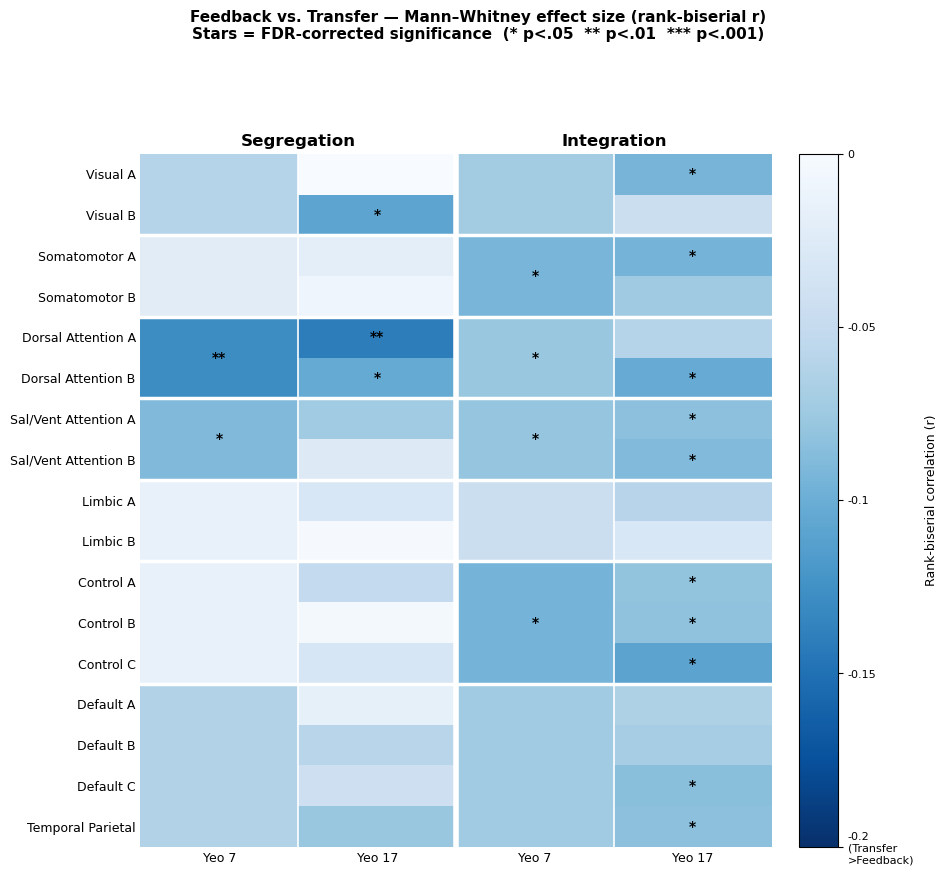

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import ks_2samp, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── Network definitions ───────────────────────────────────────────────────────
YEO7_IDS   = [1, 2, 3, 4, 5, 6, 7]
YEO7_NAMES = {
    1: "Visual",           2: "Somatomotor",
    3: "Dorsal Attention", 4: "Ventral Attention",
    5: "Limbic",           6: "Frontoparietal",
    7: "Default",
}

_YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
_YEO17_NAME_MAP = {
    "VisCent":      "Visual A",             "VisPeri":      "Visual B",
    "SomMotA":      "Somatomotor A",        "SomMotB":      "Somatomotor B",
    "DorsAttnA":    "Dorsal Attention A",   "DorsAttnB":    "Dorsal Attention B",
    "SalVentAttnA": "Sal/Vent Attention A", "SalVentAttnB": "Sal/Vent Attention B",
    "LimbicA":      "Limbic A",             "LimbicB":      "Limbic B",
    "ContA":        "Control A",            "ContB":        "Control B",
    "ContC":        "Control C",            "DefaultA":     "Default A",
    "DefaultB":     "Default B",            "DefaultC":     "Default C",
    "TempPar":      "Temporal Parietal",
}

YEO7_GROUP_SIZES = [2, 2, 2, 2, 2, 3, 4]
_starts          = [0] + list(np.cumsum(YEO7_GROUP_SIZES))
YEO17_SEPARATORS = np.cumsum(YEO7_GROUP_SIZES)[:-1] - 0.5

# ── Load & aggregate ──────────────────────────────────────────────────────────
CSV7  = "../../../Results/Tessnim/all_subjects_yeo7_metrics.csv"
CSV17 = "../../../Results/Tessnim/all_subjects_yeo17_metrics.csv"

def _load_and_agg(path):
    df = pd.read_csv(path)
    # CSV already stores r-space values (tanh applied during computation)
    df["segregation_r"] = df["segregation"]
    df["integration_r"] = df["integration"]
    return df.groupby(
        ["subject", "session", "run", "condition", "network"], as_index=False
    )[["segregation_r", "integration_r"]].mean()

df7_run  = _load_and_agg(CSV7)
df17_run = _load_and_agg(CSV17)

# ── Effect size: rank-biserial correlation ────────────────────────────────────
# r_rb = 1 - (2U) / (n1 * n2)  ranges from -1 to +1
# positive = Feedback > Transfer, negative = Transfer > Feedback
def _rank_biserial(x, y):
    nx, ny = len(x), len(y)
    U, _   = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (nx * ny)

# ── Compute stats + effect sizes ──────────────────────────────────────────────
def _compute_stats(df_run, net_ids):
    rows = []
    for metric in ["segregation_r", "integration_r"]:
        for net in net_ids:
            s  = df_run[df_run["network"] == net]
            fb = s[s["condition"] == "Feedback"][metric].values
            tr = s[s["condition"] == "Transfer"][metric].values
            if fb.size < 5 or tr.size < 5:
                rows.append({"net": net, "metric": metric,
                             "mw_p": np.nan, "r_rb": np.nan})
                continue
            _, mw_p = mannwhitneyu(fb, tr, alternative="two-sided")
            r_rb    = _rank_biserial(fb, tr)
            rows.append({"net": net, "metric": metric,
                         "mw_p": mw_p, "r_rb": r_rb})
    out = pd.DataFrame(rows)
    # FDR correction
    valid = out["mw_p"].notna()
    corr  = np.full(len(out), np.nan)
    if valid.any():
        corr[valid] = multipletests(out.loc[valid, "mw_p"], method="fdr_bh")[1]
    out["mw_p_corr"] = corr
    return out

stats7  = _compute_stats(df7_run,  YEO7_IDS)
stats17 = _compute_stats(df17_run, _YEO17_ORDER)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _star(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

# ── Build matrix + star lists ─────────────────────────────────────────────────
# Column layout:
#   col 0 = Segregation / Yeo-7   (block-expanded)
#   col 1 = Segregation / Yeo-17
#   col 2 = Integration / Yeo-7   (block-expanded)
#   col 3 = Integration / Yeo-17
#
# Colour  = rank-biserial r  (effect size, −1 to +1)
# Stars   = FDR-corrected Mann-Whitney p

def _build_combined_matrix(stats7, stats17):
    mat         = np.full((17, 4), np.nan)   # rank-biserial values
    stars_yeo7  = []   # (y_float, col, star_str, r_rb)
    stars_yeo17 = []   # (y_int,   col, star_str, r_rb)

    # Yeo-7 column — block fill
    for gi, net7 in enumerate(YEO7_IDS):
        row_start = _starts[gi]
        row_end   = _starts[gi + 1]
        y_mid     = (row_start + row_end - 1) / 2.0   # float midpoint

        for mi, metric in enumerate(["segregation_r", "integration_r"]):
            col = mi * 2
            row = stats7[(stats7["net"] == net7) & (stats7["metric"] == metric)]
            if row.empty:
                continue
            r_rb = row["r_rb"].iloc[0]
            p    = row["mw_p_corr"].iloc[0]
            mat[row_start:row_end, col] = r_rb
            s = _star(p)
            if s:
                stars_yeo7.append((y_mid, col, s, r_rb))

    # Yeo-17 columns
    for ri, net17 in enumerate(_YEO17_ORDER):
        for mi, metric in enumerate(["segregation_r", "integration_r"]):
            col = mi * 2 + 1
            row = stats17[(stats17["net"] == net17) & (stats17["metric"] == metric)]
            if row.empty:
                continue
            r_rb = row["r_rb"].iloc[0]
            p    = row["mw_p_corr"].iloc[0]
            mat[ri, col] = r_rb
            s = _star(p)
            if s:
                stars_yeo17.append((ri, col, s, r_rb))

    return mat, stars_yeo7, stars_yeo17

# ── Plot ──────────────────────────────────────────────────────────────────────
# Replace these two lines in your script:
CMAP = plt.cm.Blues_r       # one direction only, since all r_rb < 0
NORM = mcolors.Normalize(vmin=-0.2, vmax=0)   # zoom to your actual data range

SUB_LABELS = ["Yeo 7", "Yeo 17", "Yeo 7", "Yeo 17"]

def _make_figure(out_fname):
    mat, stars_yeo7, stars_yeo17 = _build_combined_matrix(stats7, stats17)

    fig = plt.figure(figsize=(9, 9))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 0.25], wspace=0.08, figure=fig)
    ax  = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.imshow(mat, cmap=CMAP, norm=NORM, aspect="auto")

    # Stars — choose black or white based on how saturated the cell is
    def _star_color(r_rb):
        return "white" if (not np.isnan(r_rb) and abs(r_rb) > 0.6) else "black"

    for y, c, s, r_rb in stars_yeo7:
        ax.text(c, y, s, ha="center", va="center",
                fontsize=10, fontweight="bold", color=_star_color(r_rb))

    for r, c, s, r_rb in stars_yeo17:
        ax.text(c, r, s, ha="center", va="center",
                fontsize=10, fontweight="bold", color=_star_color(r_rb))

    # Horizontal separators
    for b in YEO17_SEPARATORS:
        ax.axhline(b, color="white", lw=2.5, zorder=5)

    # Vertical dividers
    ax.axvline(0.5, color="white", lw=1.2, zorder=5)
    ax.axvline(1.5, color="white", lw=4.0, zorder=5)
    ax.axvline(2.5, color="white", lw=1.2, zorder=5)

    # Bottom x-axis
    ax.set_xticks(range(4))
    ax.set_xticklabels(SUB_LABELS, fontsize=9)
    ax.tick_params(axis="x", length=0)

    # Y-axis
    ax.set_yticks(range(17))
    ax.set_yticklabels([_YEO17_NAME_MAP[n] for n in _YEO17_ORDER], fontsize=9)
    ax.tick_params(axis="y", length=0)
    ax.spines[:].set_visible(False)

    # Top x-axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([0.5, 2.5])
    ax2.set_xticklabels(["Segregation", "Integration"],
                        fontsize=12, fontweight="bold")
    ax2.tick_params(length=0)
    ax2.spines[:].set_visible(False)

    # Colourbar
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), cax=cax)
    cb.set_label("Rank-biserial correlation (r)", fontsize=9, labelpad=8)
    cb.set_ticks([-0.2, -0.15, -0.1, -0.05, 0])
    cb.set_ticklabels(["-0.2\n(Transfer\n>Feedback)", "-0.15", "-0.1", "-0.05", "0"], fontsize=8)

    fig.suptitle(
        "Feedback vs. Transfer — Mann–Whitney effect size (rank-biserial r)\n"
        "Stars = FDR-corrected significance  (* p<.05  ** p<.01  *** p<.001)",
        fontsize=11, fontweight="bold", y=1.04,
    )
    plt.tight_layout()
    plt.savefig(out_fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_fname}")
    plt.show()

_make_figure(os.path.join(FIGURES_DIR, "yeo_significance_MW_effectsize.png"))

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\2585792474.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_KS_seg.png


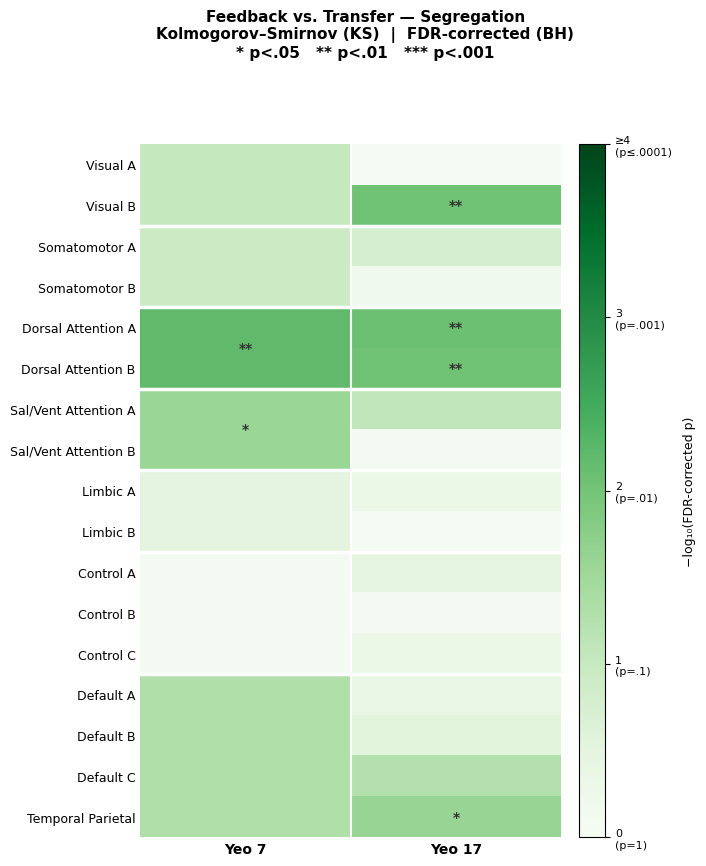

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\2585792474.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_KS_int.png


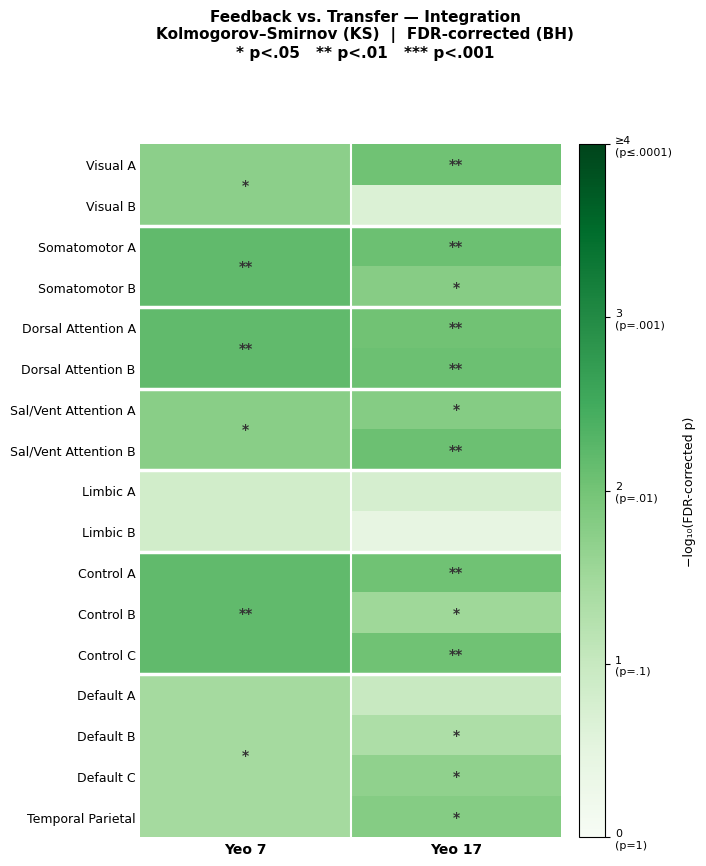

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\2585792474.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_MW_seg.png


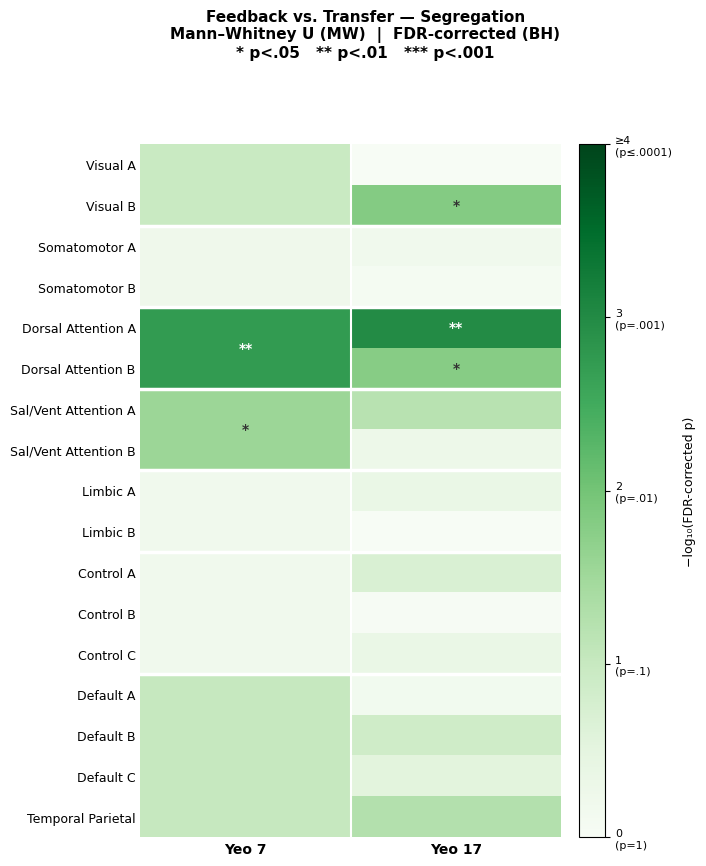

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\2585792474.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../../../Results/Tessnim/figures/yeo_MW_int.png


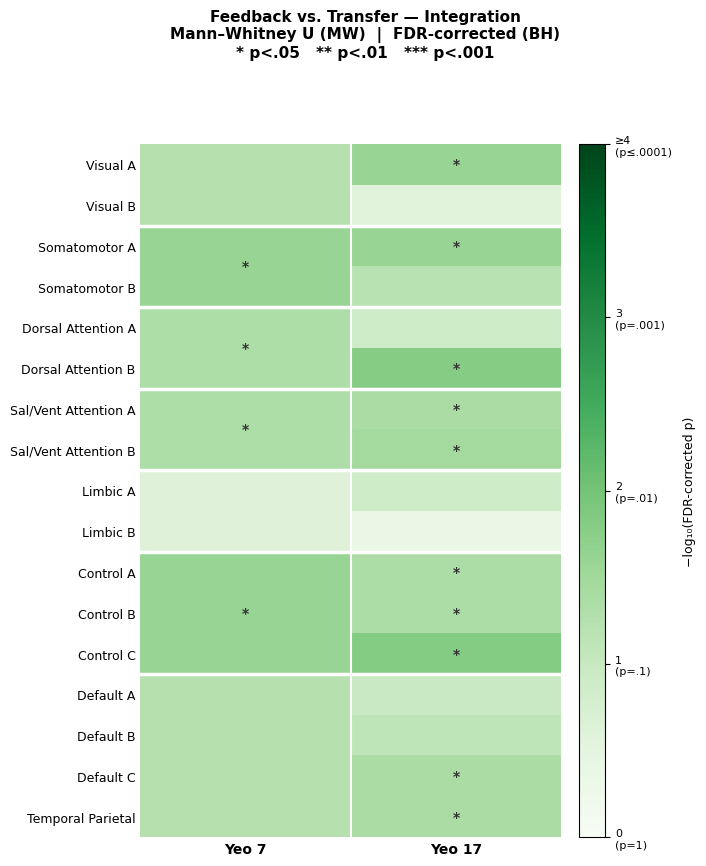

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import ks_2samp, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── Network definitions ───────────────────────────────────────────────────────
YEO7_IDS   = [1, 2, 3, 4, 5, 6, 7]
YEO7_NAMES = {
    1: "Visual",           2: "Somatomotor",
    3: "Dorsal Attention", 4: "Ventral Attention",
    5: "Limbic",           6: "Frontoparietal",
    7: "Default",
}

_YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
_YEO17_NAME_MAP = {
    "VisCent":      "Visual A",             "VisPeri":      "Visual B",
    "SomMotA":      "Somatomotor A",        "SomMotB":      "Somatomotor B",
    "DorsAttnA":    "Dorsal Attention A",   "DorsAttnB":    "Dorsal Attention B",
    "SalVentAttnA": "Sal/Vent Attention A", "SalVentAttnB": "Sal/Vent Attention B",
    "LimbicA":      "Limbic A",             "LimbicB":      "Limbic B",
    "ContA":        "Control A",            "ContB":        "Control B",
    "ContC":        "Control C",            "DefaultA":     "Default A",
    "DefaultB":     "Default B",            "DefaultC":     "Default C",
    "TempPar":      "Temporal Parietal",
}

# Yeo-7 group sizes (must sum to 17) and derived helpers
YEO7_GROUP_SIZES = [2, 2, 2, 2, 2, 3, 4]
_starts          = [0] + list(np.cumsum(YEO7_GROUP_SIZES))
YEO17_SEPARATORS = np.cumsum(YEO7_GROUP_SIZES)[:-1] - 0.5   # horizontal dividers

# ── Load & aggregate ──────────────────────────────────────────────────────────
CSV7  = "../../../Results/Tessnim/all_subjects_yeo7_metrics.csv"
CSV17 = "../../../Results/Tessnim/all_subjects_yeo17_metrics.csv"

def _load_and_agg(path):
    df = pd.read_csv(path)
    # CSV already stores r-space values (tanh applied during computation)
    df["segregation_r"] = df["segregation"]
    df["integration_r"] = df["integration"]
    return df.groupby(
        ["subject", "session", "run", "condition", "network"], as_index=False
    )[["segregation_r", "integration_r"]].mean()

df7_run  = _load_and_agg(CSV7)
df17_run = _load_and_agg(CSV17)

# ── Compute FDR-corrected KS & MW for both metrics ───────────────────────────
def _compute_stats(df_run, net_ids):
    rows = []
    for metric in ["segregation_r", "integration_r"]:
        for net in net_ids:
            s  = df_run[df_run["network"] == net]
            fb = s[s["condition"] == "Feedback"][metric].values
            tr = s[s["condition"] == "Transfer"][metric].values
            if fb.size < 5 or tr.size < 5:
                rows.append({"net": net, "metric": metric,
                             "ks_p": np.nan, "mw_p": np.nan})
                continue
            _, ks_p = ks_2samp(fb, tr, alternative="two-sided")
            _, mw_p = mannwhitneyu(fb, tr, alternative="two-sided")
            rows.append({"net": net, "metric": metric,
                         "ks_p": ks_p, "mw_p": mw_p})
    out = pd.DataFrame(rows)
    for col in ["ks_p", "mw_p"]:
        valid = out[col].notna()
        corr  = np.full(len(out), np.nan)
        if valid.any():
            corr[valid] = multipletests(out.loc[valid, col], method="fdr_bh")[1]
        out[f"{col}_corr"] = corr
    return out

stats7  = _compute_stats(df7_run,  YEO7_IDS)
stats17 = _compute_stats(df17_run, _YEO17_ORDER)

# ── Helpers ───────────────────────────────────────────────────────────────────
def _pval_to_neg_log(p):
    return np.clip(-np.log10(max(p, 1e-10)), 0, 4) if pd.notna(p) else np.nan

def _star(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

# ── Build 17×2 matrix for one test + one metric ──────────────────────────────
# col 0 = Yeo-7  (block-expanded, star at float midpoint of each group)
# col 1 = Yeo-17 (one row per sub-network)

def _build_matrix(test_col, metric):
    mat         = np.full((17, 2), np.nan)
    stars_yeo7  = []   # (y_float, col, star_str, value)
    stars_yeo17 = []   # (y_int,   col, star_str, value)

    # Yeo-7 column (col 0) — block fill
    for gi, net7 in enumerate(YEO7_IDS):
        row_start = _starts[gi]
        row_end   = _starts[gi + 1]
        y_mid     = (row_start + row_end - 1) / 2.0   # true float midpoint

        row = stats7[(stats7["net"] == net7) & (stats7["metric"] == metric)]
        if row.empty:
            continue
        p = row[test_col].iloc[0]
        v = _pval_to_neg_log(p)
        mat[row_start:row_end, 0] = v
        s = _star(p)
        if s:
            stars_yeo7.append((y_mid, 0, s, v))

    # Yeo-17 column (col 1) — one row per sub-network
    for ri, net17 in enumerate(_YEO17_ORDER):
        row = stats17[(stats17["net"] == net17) & (stats17["metric"] == metric)]
        if row.empty:
            continue
        p = row[test_col].iloc[0]
        v = _pval_to_neg_log(p)
        mat[ri, 1] = v
        s = _star(p)
        if s:
            stars_yeo17.append((ri, 1, s, v))

    return mat, stars_yeo7, stars_yeo17

# ── Plot ──────────────────────────────────────────────────────────────────────
CMAP = plt.cm.Greens
NORM = mcolors.Normalize(vmin=0, vmax=4)

def _make_figure(test_col, test_label, metric, metric_label, out_fname):
    mat, stars_yeo7, stars_yeo17 = _build_matrix(test_col, metric)

    fig = plt.figure(figsize=(6, 9))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 0.25], wspace=0.08, figure=fig)
    ax  = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    ax.imshow(mat, cmap=CMAP, norm=NORM, aspect="auto")

    # Yeo-7 stars at float midpoint of each block
    for y, c, s, v in stars_yeo7:
        color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax.text(c, y, s, ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)

    # Yeo-17 stars at integer row
    for r, c, s, v in stars_yeo17:
        color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax.text(c, r, s, ha="center", va="center",
                fontsize=10, fontweight="bold", color=color)

    # Horizontal separators (network group boundaries)
    for b in YEO17_SEPARATORS:
        ax.axhline(b, color="white", lw=2.5, zorder=5)

    # Vertical divider between Yeo-7 and Yeo-17
    ax.axvline(0.5, color="white", lw=1.5, zorder=5)

    # X-axis
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Yeo 7", "Yeo 17"], fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", length=0)

    # Y-axis: Yeo-17 network names
    ax.set_yticks(range(17))
    ax.set_yticklabels([_YEO17_NAME_MAP[n] for n in _YEO17_ORDER], fontsize=9)
    ax.tick_params(axis="y", length=0)
    ax.spines[:].set_visible(False)

    # Colourbar
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), cax=cax)
    cb.set_label("−log₁₀(FDR-corrected p)", fontsize=9, labelpad=8)
    cb.set_ticks([0, 1, 2, 3, 4])
    cb.set_ticklabels(
        ["0\n(p=1)", "1\n(p=.1)", "2\n(p=.01)", "3\n(p=.001)", "≥4\n(p≤.0001)"],
        fontsize=8,
    )

    fig.suptitle(
        f"Feedback vs. Transfer — {metric_label}\n"
        f"{test_label}  |  FDR-corrected (BH)\n"
        "* p<.05   ** p<.01   *** p<.001",
        fontsize=11, fontweight="bold", y=1.03,
    )
    plt.tight_layout()
    plt.savefig(out_fname, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_fname}")
    plt.show()

# ── Generate 4 figures (2 tests × 2 metrics) ─────────────────────────────────
for test_col, test_label, t_short in [
    ("ks_p_corr", "Kolmogorov–Smirnov (KS)", "KS"),
    ("mw_p_corr", "Mann–Whitney U (MW)",      "MW"),
]:
    for metric, metric_label, m_short in [
        ("segregation_r", "Segregation", "seg"),
        ("integration_r", "Integration", "int"),
    ]:
        _make_figure(
            test_col, test_label,
            metric, metric_label,
            os.path.join(FIGURES_DIR, f"yeo_{t_short}_{m_short}.png"),
        )

Saved: ../../../Results/Tessnim/figures/slide1_seg_fb_vs_tr.png


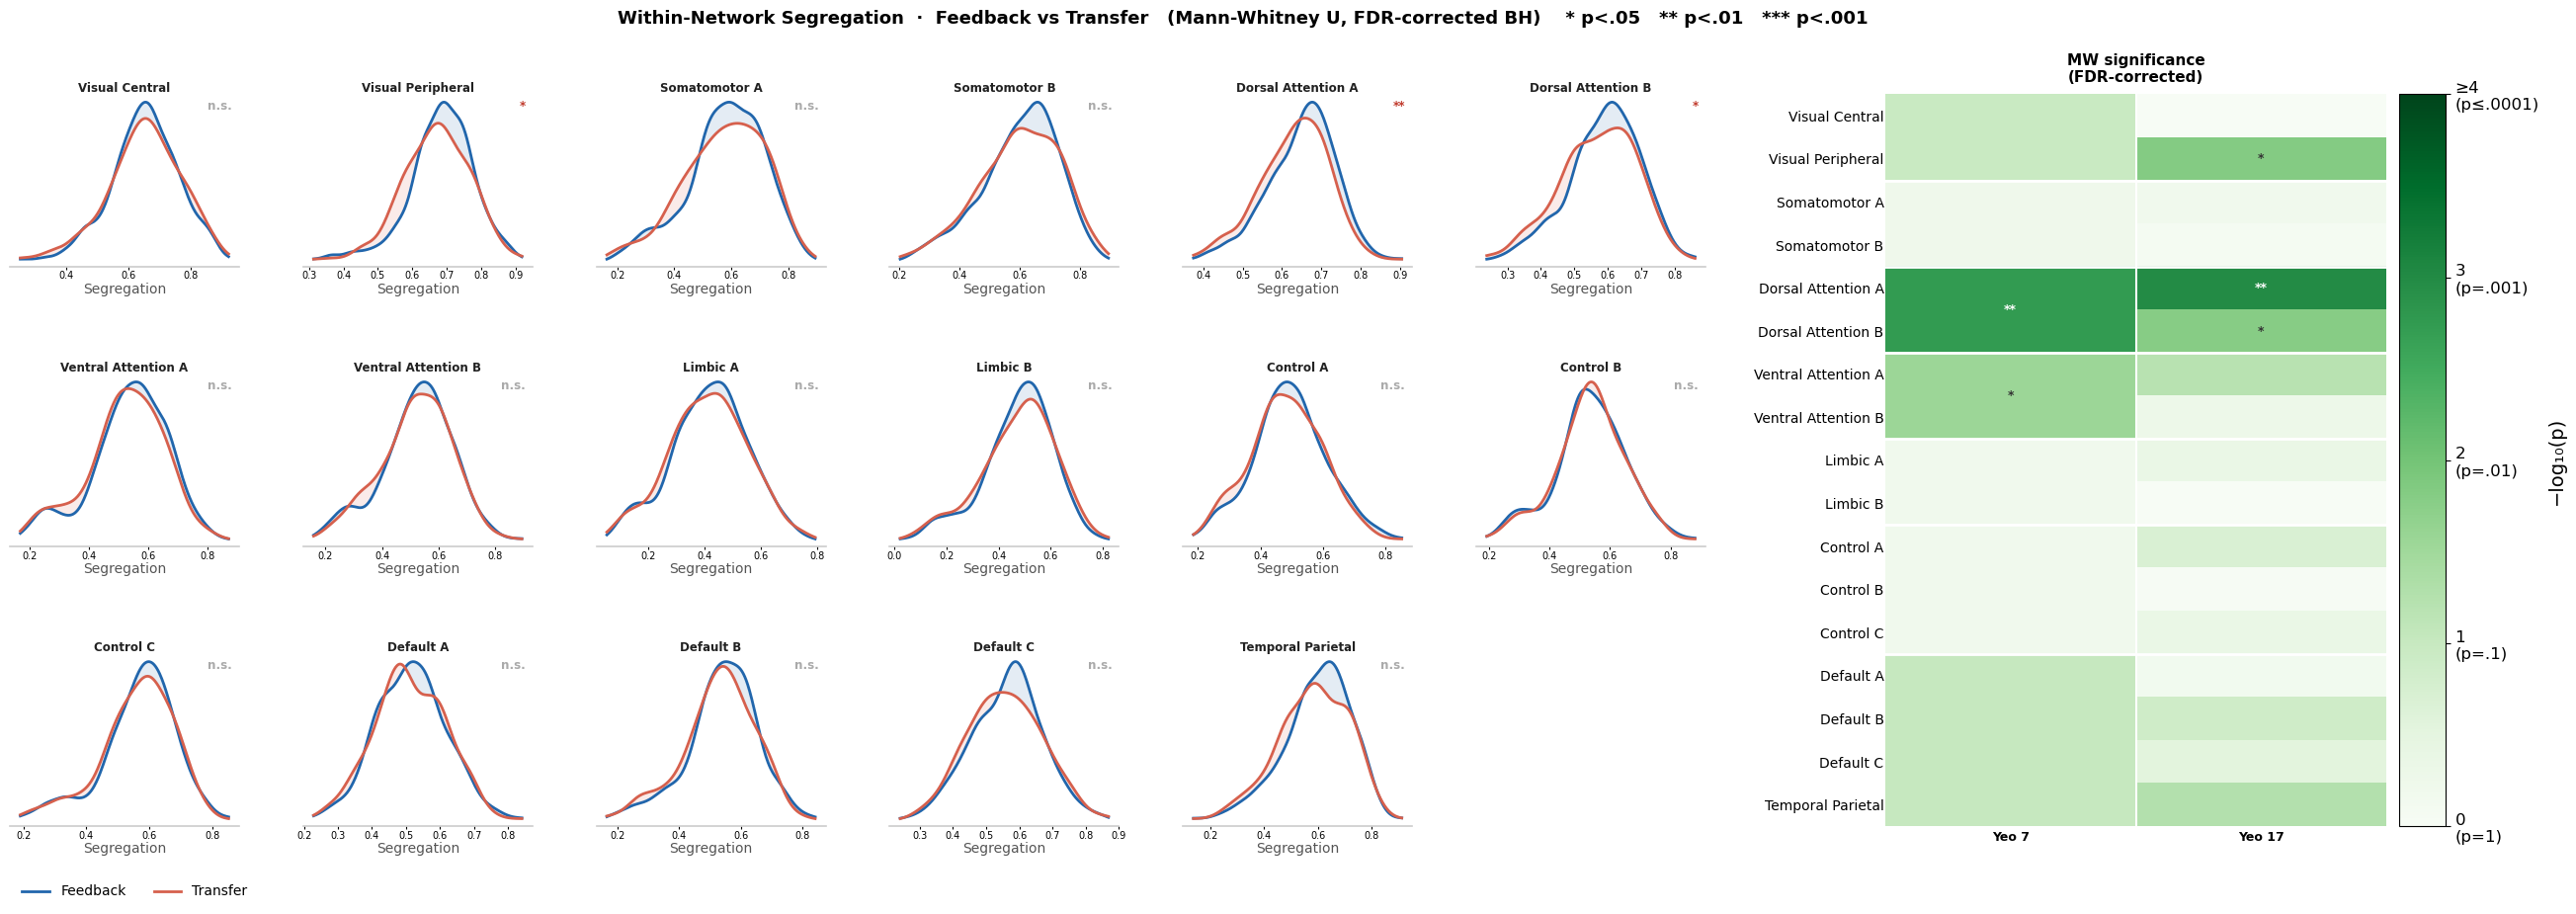

Saved: ../../../Results/Tessnim/figures/slide2_int_fb_vs_tr.png


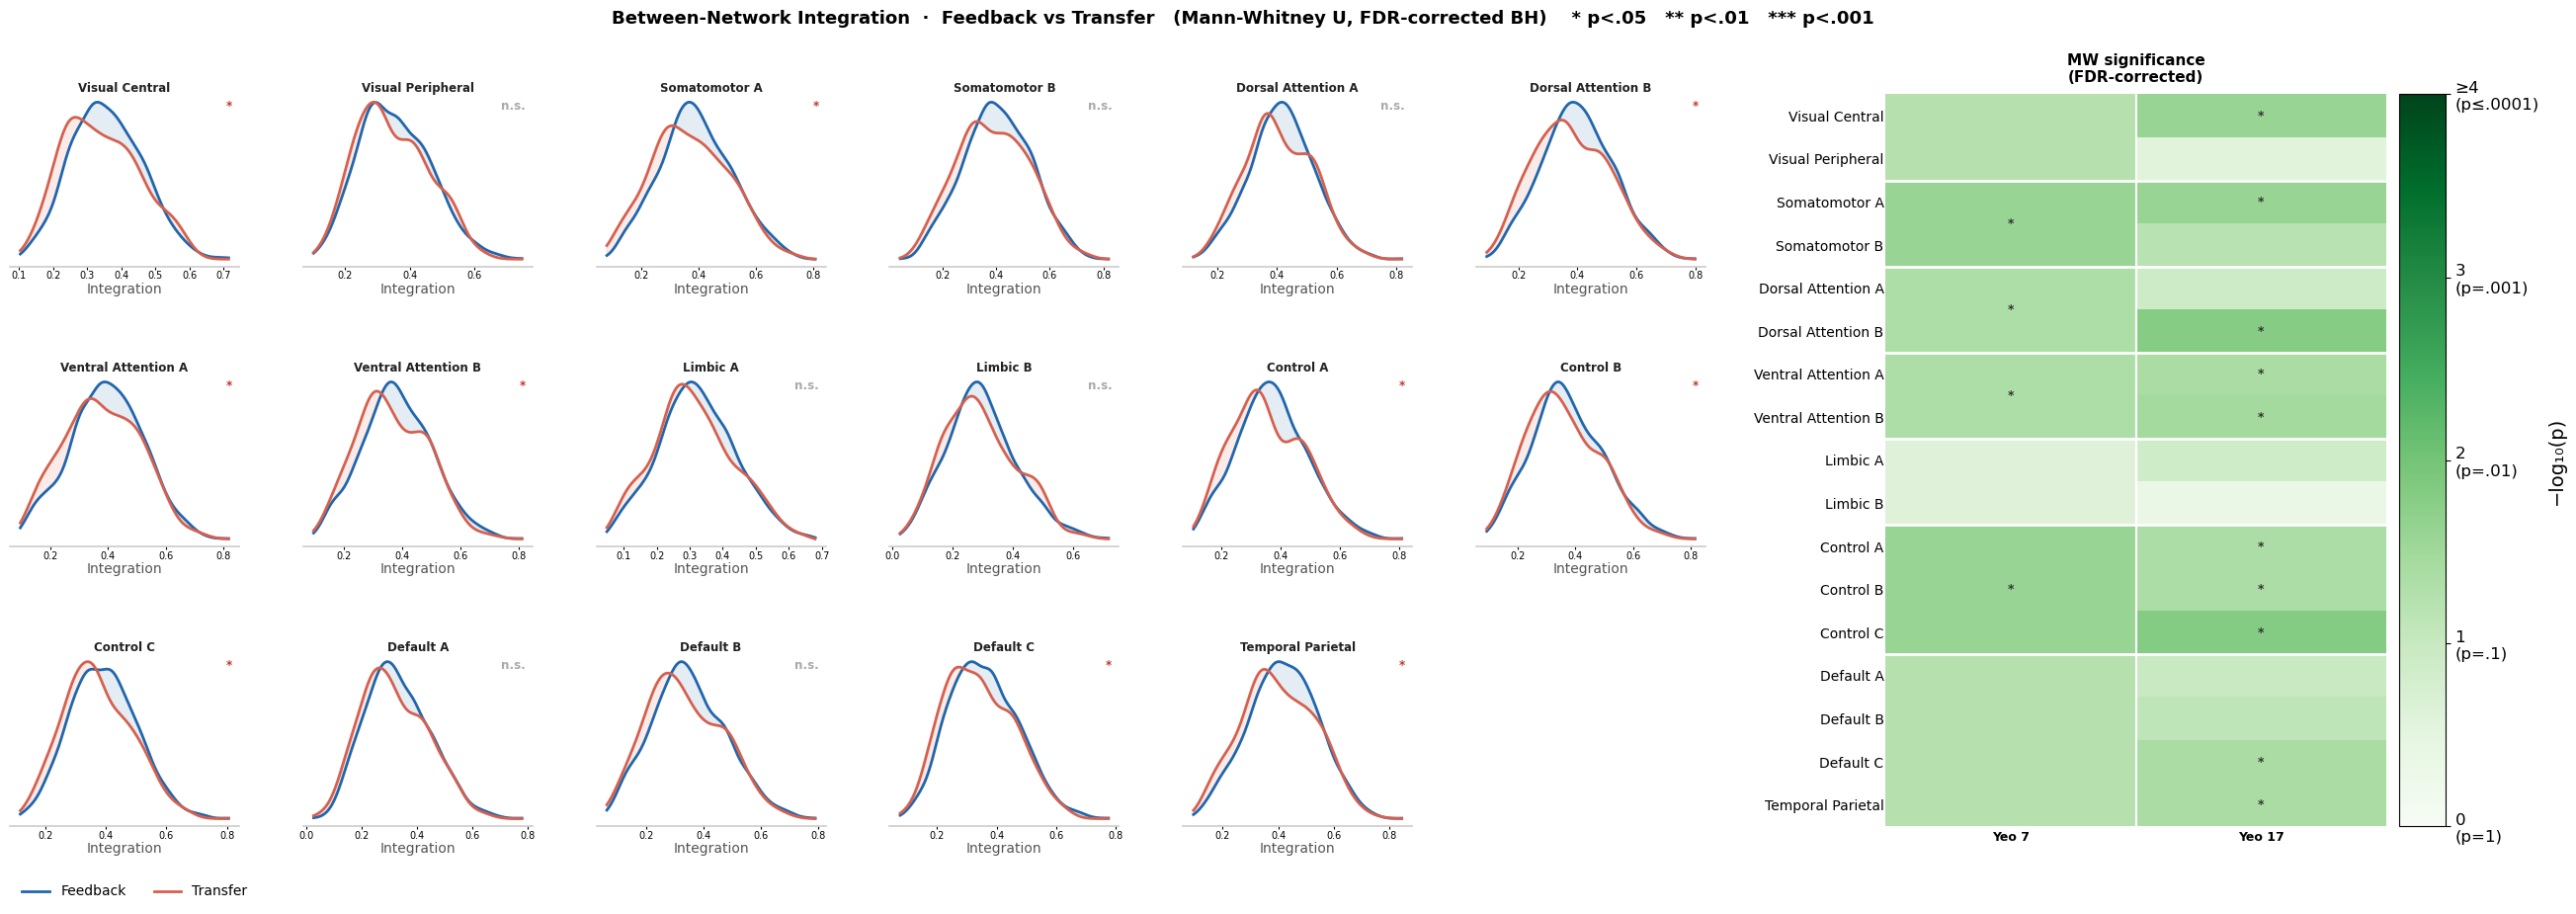

Saved: ../../../Results/Tessnim/figures/slide3_seg_early_vs_late.png


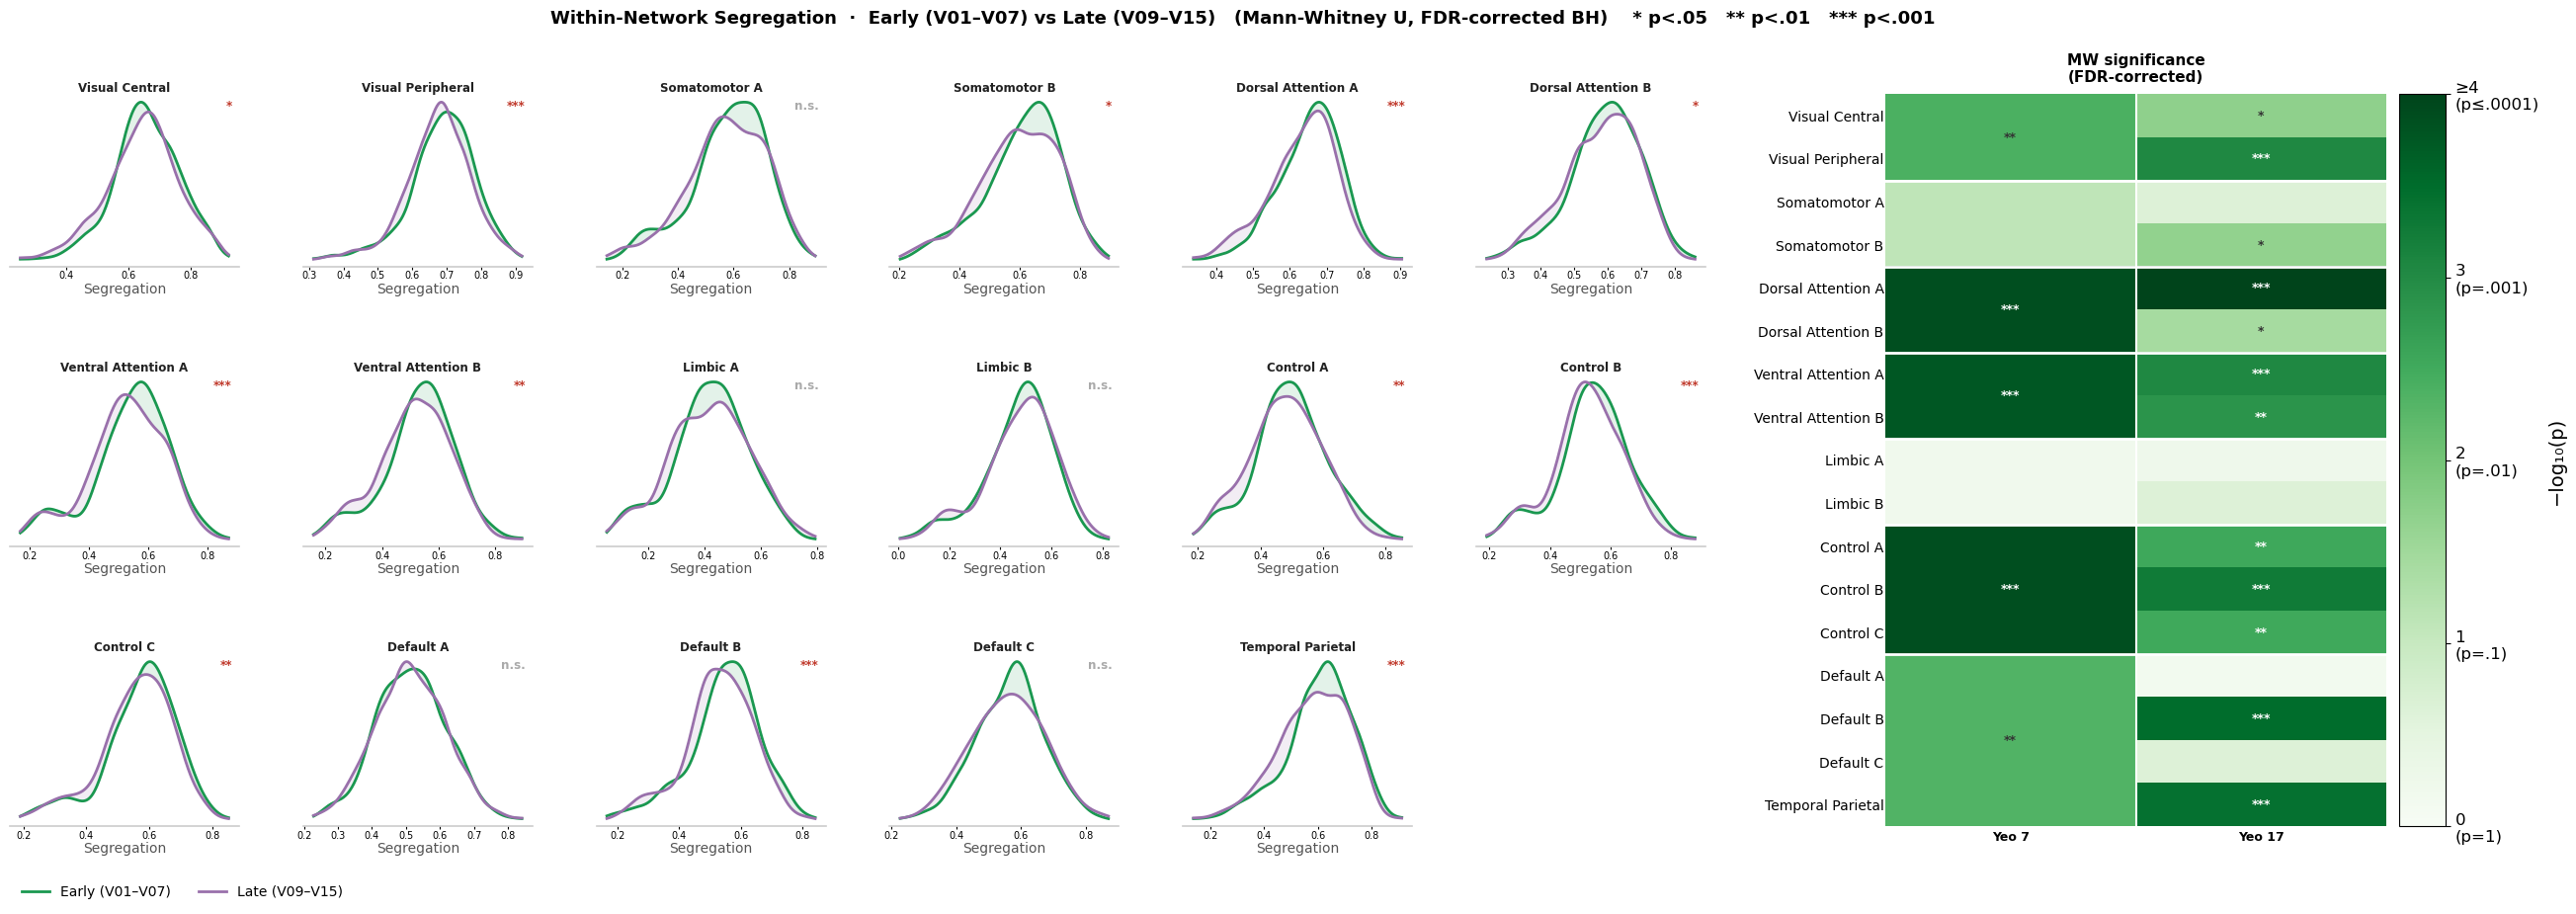

Saved: ../../../Results/Tessnim/figures/slide4_int_early_vs_late.png


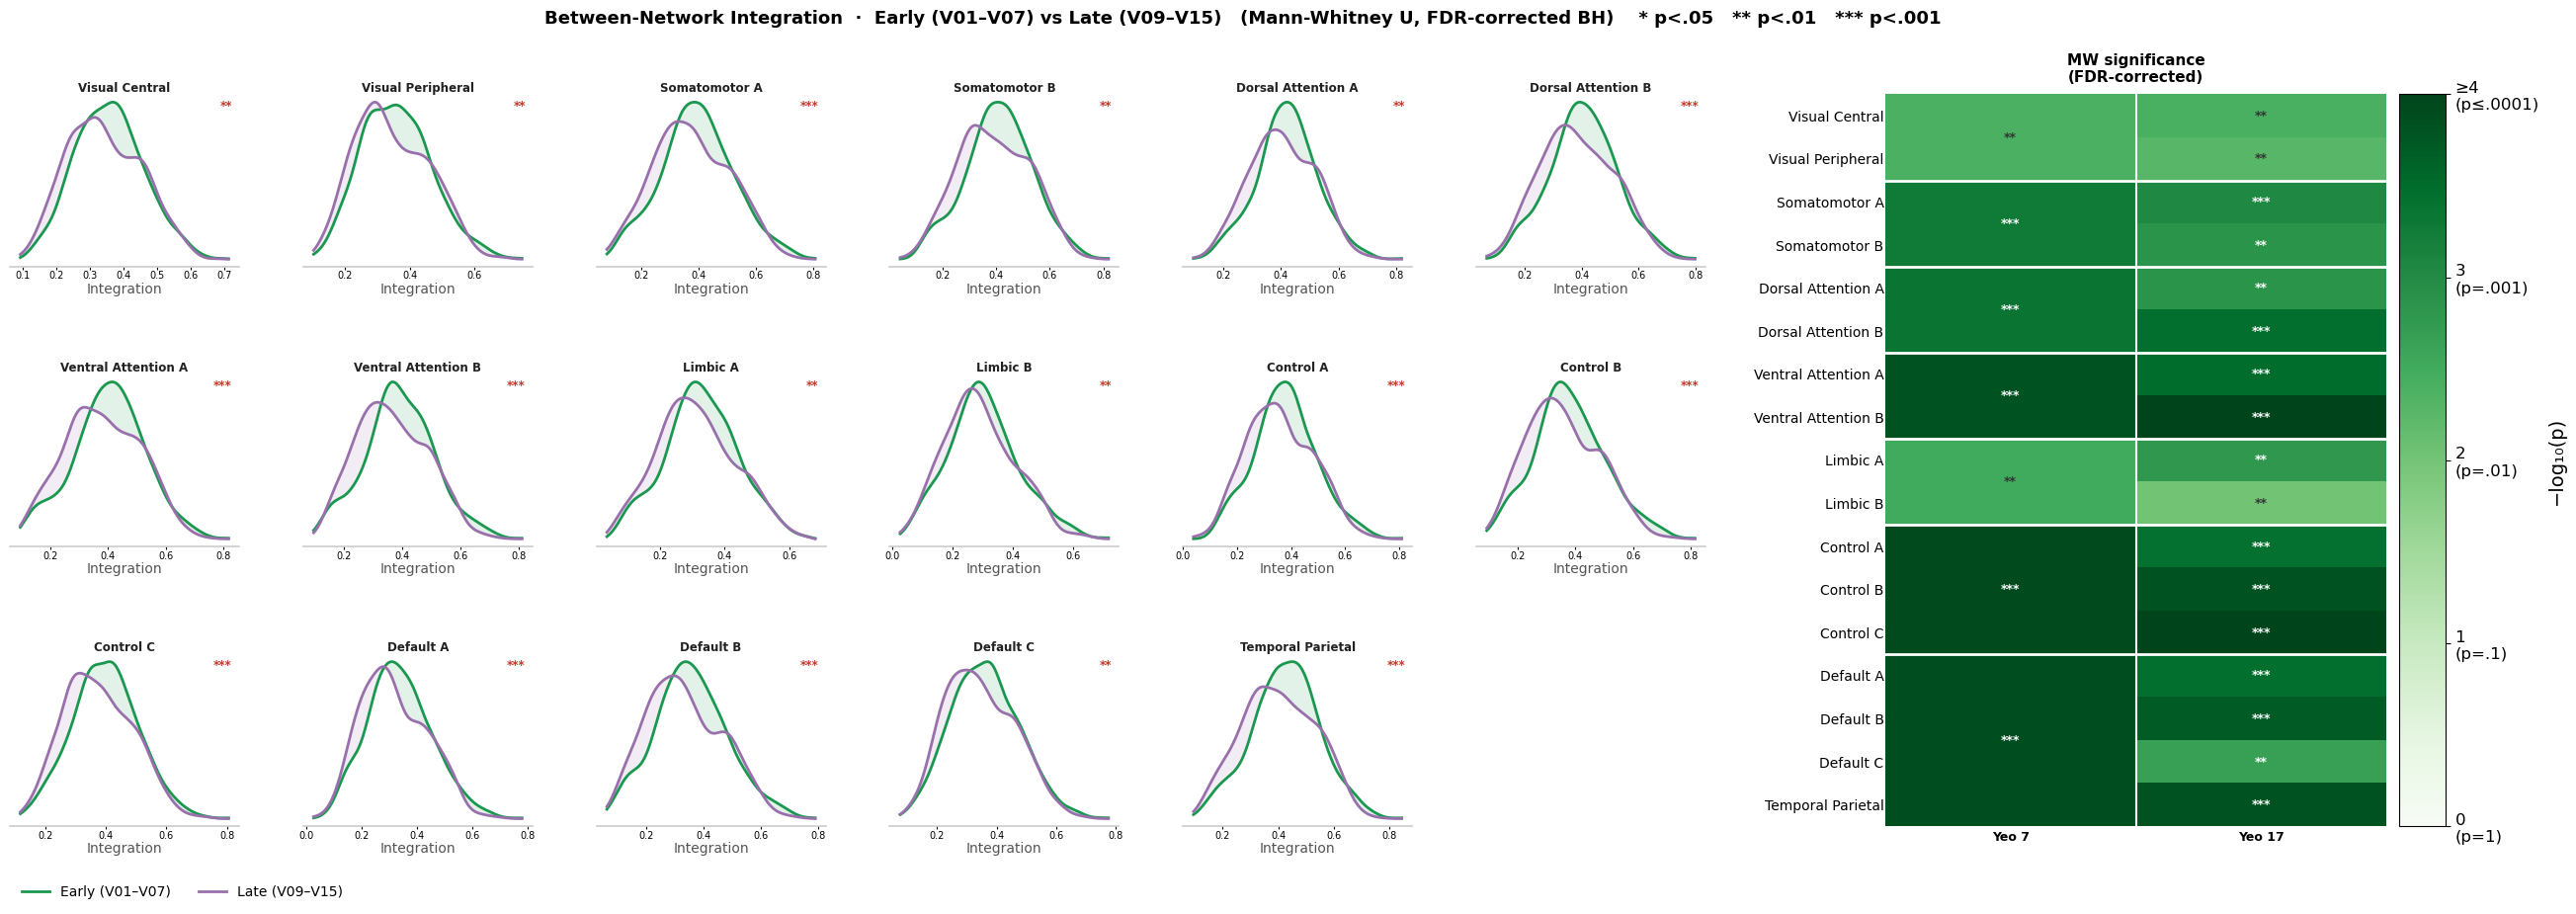

In [9]:
"""
Drop this as a single new cell AFTER your data-loading cells (df_run, df7_run already defined).
Produces 4 slide-ready PNGs (16:9, ~1600×900 px):
  slide1_seg_fb_vs_tr.png    – Segregation, Feedback vs Transfer
  slide2_int_fb_vs_tr.png    – Integration,  Feedback vs Transfer
  slide3_seg_early_vs_late.png – Segregation, Early vs Late
  slide4_int_early_vs_late.png – Integration,  Early vs Late

Each figure:  KDE distributions (left 75%) | significance heatmap (right 25%)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde, mannwhitneyu, ks_2samp
from statsmodels.stats.multitest import multipletests

# ── Atlas constants ───────────────────────────────────────────────────────────
YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO17_NAME_MAP = {
    "VisCent":      "Visual Central",             "VisPeri":      "Visual Peripheral",
    "SomMotA":      "Somatomotor A",              "SomMotB":      "Somatomotor B",
    "DorsAttnA":    "Dorsal Attention A",          "DorsAttnB":    "Dorsal Attention B",
    "SalVentAttnA": "Ventral Attention A",          "SalVentAttnB": "Ventral Attention B",
    "LimbicA":      "Limbic A",                   "LimbicB":      "Limbic B",
    "ContA":        "Control A",                  "ContB":        "Control B",
    "ContC":        "Control C",                  "DefaultA":     "Default A",
    "DefaultB":     "Default B",                  "DefaultC":     "Default C",
    "TempPar":      "Temporal Parietal",
}

YEO7_IDS   = [1, 2, 3, 4, 5, 6, 7]
YEO7_NAMES = {
    1: "Visual",  2: "Somatomotor",  3: "Dorsal Attn",
    4: "Vent Attn",  5: "Limbic",  6: "Frontoparietal",  7: "Default",
}
YEO7_GROUP_SIZES = [2, 2, 2, 2, 2, 3, 4]
_starts          = [0] + list(np.cumsum(YEO7_GROUP_SIZES))
YEO17_SEPARATORS = np.cumsum(YEO7_GROUP_SIZES)[:-1] - 0.5

# Per-network colors (canonical Yeo atlas palette)
YEO17_COLORS = {
    "VisCent": "#7B2D8B",  "VisPeri": "#A155B9",
    "SomMotA": "#4393C3",  "SomMotB": "#74ADD1",
    "DorsAttnA": "#1A9850","DorsAttnB": "#66BD63",
    "SalVentAttnA": "#D73027","SalVentAttnB": "#F46D43",
    "LimbicA": "#C8A400",  "LimbicB": "#E8CC44",
    "ContA": "#E08020",    "ContB": "#EAA060",   "ContC": "#F4C090",
    "DefaultA": "#878787", "DefaultB": "#BABABA","DefaultC": "#E0E0E0",
    "TempPar": "#BF812D",
}
YEO7_COLORS = {
    1: "#7B2D8B", 2: "#4393C3", 3: "#1A9850",
    4: "#D73027", 5: "#C8A400", 6: "#E08020", 7: "#878787",
}

# ── Condition color pairs ─────────────────────────────────────────────────────
COND_COLORS = {
    "Feedback": "#2166AC",
    "Transfer": "#D6604D",
    "Early":    "#1A9850",
    "Late":     "#9970AB",
}

LINE_WIDTH = 2.0

# ── Helpers ───────────────────────────────────────────────────────────────────
def p_to_stars(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."

def pval_to_neg_log(p):
    if pd.isna(p): return np.nan
    return float(np.clip(-np.log10(max(p, 1e-10)), 0, 4))

# ── Build early/late dataframe (no column collision) ─────────────────────────
def make_early_late_df(df_src, early_sessions, late_sessions):
    """Returns a copy of df_src with 'condition' replaced by Early/Late labels."""
    d = df_src.copy()
    mask_early = d["session"].isin(early_sessions)
    mask_late  = d["session"].isin(late_sessions)
    d = d[mask_early | mask_late].copy()
    d["condition"] = np.where(d["session"].isin(early_sessions), "Early", "Late")
    return d

# ── Compute FDR-corrected MW + KS for one dataframe ──────────────────────────
def compute_stats(df_run, net_ids, cond_a, cond_b, metrics):
    rows = []
    for metric in metrics:                          # ← loop over metrics
        for net in net_ids:
            s  = df_run[df_run["network"] == net]
            va = s[s["condition"] == cond_a][metric].dropna().values
            vb = s[s["condition"] == cond_b][metric].dropna().values
            if va.size < 5 or vb.size < 5:
                rows.append({"net": net, "metric": metric, "mw_p": np.nan, "ks_p": np.nan})
                continue
            _, mw_p = mannwhitneyu(va, vb, alternative="two-sided")
            _, ks_p = ks_2samp(va, vb, alternative="two-sided")
            rows.append({"net": net, "metric": metric, "mw_p": mw_p, "ks_p": ks_p})
    out = pd.DataFrame(rows)
    for col in ["mw_p", "ks_p"]:                   # FDR over all nets × metrics
        valid = out[col].notna()
        corr  = np.full(len(out), np.nan)
        if valid.any():
            corr[valid] = multipletests(out.loc[valid, col], method="fdr_bh")[1]
        out[f"{col}_corr"] = corr
    return out


# ── Build 17×2 heatmap matrix ────────────────────────────────────────────────
def build_heatmap_matrix(stats7, stats17, test_col):
    """
    Returns mat (17×2): col0=Yeo7 block-expanded, col1=Yeo17 per-network.
    Also returns star annotation lists.
    """
    mat         = np.full((17, 2), np.nan)
    stars_yeo7  = []   # (y_float, col, star_str, value)
    stars_yeo17 = []   # (y_int,   col, star_str, value)

    # Yeo-7: block fill
    for gi, net7 in enumerate(YEO7_IDS):
        row_start = _starts[gi]
        row_end   = _starts[gi + 1]
        y_mid     = (row_start + row_end - 1) / 2.0
        row = stats7[stats7["net"] == net7]
        if row.empty: continue
        p = row[test_col].iloc[0]
        v = pval_to_neg_log(p)
        mat[row_start:row_end, 0] = v
        s = p_to_stars(p)
        if s and s != "n.s.":
            stars_yeo7.append((y_mid, 0, s, v))

    # Yeo-17
    for ri, net17 in enumerate(YEO17_ORDER):
        row = stats17[stats17["net"] == net17]
        if row.empty: continue
        p = row[test_col].iloc[0]
        v = pval_to_neg_log(p)
        mat[ri, 1] = v
        s = p_to_stars(p)
        if s and s != "n.s.":
            stars_yeo17.append((ri, 1, s, v))

    return mat, stars_yeo7, stars_yeo17

# ── KDE data computation ──────────────────────────────────────────────────────
def compute_kde(df_run, net_ids, cond_a, cond_b, metric):
    kde_store = {}
    for net in net_ids:
        s  = df_run[df_run["network"] == net]
        va = s[s["condition"] == cond_a][metric].dropna().values
        vb = s[s["condition"] == cond_b][metric].dropna().values
        if va.size < 5 or vb.size < 5:
            kde_store[net] = None
            continue
        lo = min(va.min(), vb.min())
        hi = max(va.max(), vb.max())
        xg = np.linspace(lo, hi, 300)
        kde_store[net] = {
            "xg": xg,
            "d_a": gaussian_kde(va)(xg),
            "d_b": gaussian_kde(vb)(xg),
        }
    return kde_store

# ═══════════════════════════════════════════════════════════════════════════════
# Main figure builder
# ═══════════════════════════════════════════════════════════════════════════════
HMAP_CMAP = plt.cm.Greens
HMAP_NORM = mcolors.Normalize(vmin=0, vmax=4)

def make_slide_figure(
    df17, df7,
    metric, metric_label, xlabel,
    cond_a, cond_b, label_a, label_b,
    out_fname,
):
    """
    Combined slide figure: KDE grid (left) + significance heatmap (right).
    Sized for 16:9 presentation slides (19.2 × 10 inches → 200 dpi = 3840×2000).
    """
    net_ids17 = [n for n in YEO17_ORDER if n in df17["network"].unique()]
    net_ids7  = sorted(df7["network"].unique())

    # ── Compute stats ─────────────────────────────────────────────────────────
    _all17  = compute_stats(df17, net_ids17, cond_a, cond_b, ["segregation_r", "integration_r"])
    _all7   = compute_stats(df7,  net_ids7,  cond_a, cond_b, ["segregation_r", "integration_r"])
    stats17 = _all17[_all17["metric"] == metric].drop(columns="metric")
    stats7  = _all7[_all7["metric"]  == metric].drop(columns="metric")

    # Attach p_corr back to KDE store for star display
    p_corr_map17 = dict(zip(stats17["net"], stats17["mw_p_corr"]))

    # ── KDE ───────────────────────────────────────────────────────────────────
    kde17 = compute_kde(df17, net_ids17, cond_a, cond_b, metric)

    # ── Layout: 16:9, left=distributions, right=heatmap+cbar ─────────────────
    # GridSpec columns: [KDE_panels... | heatmap | colorbar]
    # We use a nested approach: outer splits left (75%) / right (25%)
    # 26×9.5: extra width so heatmap y-labels never bleed into KDE panels
    fig = plt.figure(figsize=(26, 9.5), facecolor="white")

    # KDE occupies [left=0.02 .. right=0.74], heatmap [left=0.77 .. right=0.93], cbar [0.94..0.97]
    # These are in figure-fraction units – completely independent, no shared GridSpec.
    KDE_L, KDE_R = 0.02, 0.68
    HM_L,  HM_R  = 0.75, 0.945
    CB_L,  CB_R  = 0.950, 0.968
    TOP, BOT      = 0.87, 0.09

    # ── Left: 3-row × 6-col KDE grid (17 nets + 1 hidden) ───────────────────
    n_cols_kde = 6
    n_rows_kde = int(np.ceil(len(net_ids17) / n_cols_kde))   # = 3
    kde_gs = gridspec.GridSpec(
        n_rows_kde, n_cols_kde,
        left=KDE_L, right=KDE_R, top=TOP, bottom=BOT,
        hspace=0.62, wspace=0.28,
        figure=fig,
    )

    color_a = COND_COLORS[cond_a]
    color_b = COND_COLORS[cond_b]

    for i, net in enumerate(net_ids17):
        row_i = i // n_cols_kde
        col_i = i %  n_cols_kde
        ax = fig.add_subplot(kde_gs[row_i, col_i])

        d = kde17.get(net)

        # Uniform spine styling – light grey bottom only
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.spines["bottom"].set_color("#cccccc")
        ax.spines["bottom"].set_linewidth(1.2)

        if d is None:
            ax.text(0.5, 0.5, "n/a", ha="center", va="center",
                    transform=ax.transAxes, color="#aaa", fontsize=8)
        else:
            ax.plot(d["xg"], d["d_a"], lw=LINE_WIDTH, color=color_a)
            ax.plot(d["xg"], d["d_b"], lw=LINE_WIDTH, color=color_b)
            ax.fill_between(d["xg"], d["d_a"], d["d_b"],
                            where=(d["d_a"] >= d["d_b"]),
                            alpha=0.12, color=color_a, interpolate=True)
            ax.fill_between(d["xg"], d["d_a"], d["d_b"],
                            where=(d["d_a"] <  d["d_b"]),
                            alpha=0.12, color=color_b, interpolate=True)

            p_corr = p_corr_map17.get(net, np.nan)
            stars  = p_to_stars(p_corr)
            sig_color = "#C0392B" if stars not in ("n.s.", "") else "#aaa"
            if stars:
                ax.text(0.97, 0.97, stars,
                        transform=ax.transAxes, ha="right", va="top",
                        fontsize=8.5, color=sig_color, fontweight="bold")

        # Title with short network name
        ax.set_title(YEO17_NAME_MAP[net], fontsize=8.5, fontweight="bold",
                     color="#222", pad=2)
        ax.set_xlabel(xlabel, fontsize=10, color="#555", labelpad=1)
        ax.set_yticks([])
        ax.tick_params(axis="x", labelsize=7, length=2, pad=1)

    # Hide unused panels
    for j in range(len(net_ids17), n_rows_kde * n_cols_kde):
        fig.add_subplot(kde_gs[j // n_cols_kde, j % n_cols_kde]).set_visible(False)

    # Shared legend – placed below first panel row
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=color_a, lw=LINE_WIDTH, label=label_a),
        Line2D([0], [0], color=color_b, lw=LINE_WIDTH, label=label_b),
    ]
    fig.legend(
        handles=legend_elements,
        loc="lower left",
        bbox_to_anchor=(0.02, 0.0),
        fontsize=10, frameon=False, ncol=2,
    )

    # ── Right: heatmap + colorbar – absolutely positioned, no overlap possible ─
    ax_hm = fig.add_axes([HM_L, BOT, HM_R - HM_L, TOP - BOT])
    ax_cb = fig.add_axes([CB_L, BOT, CB_R - CB_L, TOP - BOT])

    mat, stars7, stars17 = build_heatmap_matrix(stats7, stats17, "mw_p_corr")
    ax_hm.imshow(mat, cmap=HMAP_CMAP, norm=HMAP_NORM, aspect="auto")

    # Stars
    for y, c, s, v in stars7:
        col_txt = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax_hm.text(c, y, s, ha="center", va="center",
                   fontsize=9, fontweight="bold", color=col_txt)
    for r, c, s, v in stars17:
        col_txt = "white" if (not np.isnan(v) and v > 2.5) else "#333"
        ax_hm.text(c, r, s, ha="center", va="center",
                   fontsize=9, fontweight="bold", color=col_txt)

    # Separators
    for b in YEO17_SEPARATORS:
        ax_hm.axhline(b, color="white", lw=2.0, zorder=5)
    ax_hm.axvline(0.5, color="white", lw=1.5, zorder=5)

    # Axes labels
    ax_hm.set_xticks([0, 1])
    ax_hm.set_xticklabels(["Yeo 7", "Yeo 17"], fontsize=9, fontweight="bold")
    ax_hm.tick_params(axis="x", length=0)
    ax_hm.set_yticks(range(17))
    ax_hm.set_yticklabels(
        [YEO17_NAME_MAP[n] for n in YEO17_ORDER],
        fontsize=10, ha="right",
    )
    ax_hm.tick_params(axis="y", length=0, pad=1)
    ax_hm.spines[:].set_visible(False)
    ax_hm.set_title("MW significance\n(FDR-corrected)", fontsize=11,
                    fontweight="bold", pad=9)

    # Colorbar
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=HMAP_NORM, cmap=HMAP_CMAP), cax=ax_cb
    )
    cb.set_label("−log₁₀(p)", fontsize=14, labelpad=6)
    cb.set_ticks([0, 1, 2, 3, 4])
    cb.set_ticklabels(["0\n(p=1)", "1\n(p=.1)", "2\n(p=.01)",
                       "3\n(p=.001)", "≥4\n(p≤.0001)"], fontsize=12)

    # ── Title ─────────────────────────────────────────────────────────────────
    fig.suptitle(
        f"{metric_label}  ·  {label_a} vs {label_b}   "
        f"(Mann-Whitney U, FDR-corrected BH)    "
        "* p<.05   ** p<.01   *** p<.001",
        fontsize=13, fontweight="bold", y=0.96,
    )

    fig.savefig(out_fname, dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_fname}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# Generate all 4 slides
# ═══════════════════════════════════════════════════════════════════════════════

EARLY_SESSIONS = ["V01", "V02", "V03", "V04", "V05", "V06", "V07"]
LATE_SESSIONS  = ["V09", "V10", "V11", "V12", "V13", "V14", "V15"]

df_el17 = make_early_late_df(df_run,  EARLY_SESSIONS, LATE_SESSIONS)
df_el7  = make_early_late_df(df7_run, EARLY_SESSIONS, LATE_SESSIONS)

# Slide 1 – Segregation, Feedback vs Transfer
make_slide_figure(
    df17=df_run, df7=df7_run,
    metric="segregation_r", metric_label="Within-Network Segregation",
    xlabel="Segregation",
    cond_a="Feedback", cond_b="Transfer",
    label_a="Feedback", label_b="Transfer",
    out_fname=os.path.join(FIGURES_DIR, "slide1_seg_fb_vs_tr.png"),
)

# Slide 2 – Integration, Feedback vs Transfer
make_slide_figure(
    df17=df_run, df7=df7_run,
    metric="integration_r", metric_label="Between-Network Integration",
    xlabel="Integration",
    cond_a="Feedback", cond_b="Transfer",
    label_a="Feedback", label_b="Transfer",
    out_fname=os.path.join(FIGURES_DIR, "slide2_int_fb_vs_tr.png"),
)

# Slide 3 – Segregation, Early vs Late
make_slide_figure(
    df17=df_el17, df7=df_el7,
    metric="segregation_r", metric_label="Within-Network Segregation",
    xlabel="Segregation",
    cond_a="Early", cond_b="Late",
    label_a="Early (V01–V07)", label_b="Late (V09–V15)",
    out_fname=os.path.join(FIGURES_DIR, "slide3_seg_early_vs_late.png"),
)

# Slide 4 – Integration, Early vs Late
make_slide_figure(
    df17=df_el17, df7=df_el7,
    metric="integration_r", metric_label="Between-Network Integration",
    xlabel="Integration",
    cond_a="Early", cond_b="Late",
    label_a="Early (V01–V07)", label_b="Late (V09–V15)",
    out_fname=os.path.join(FIGURES_DIR, "slide4_int_early_vs_late.png"),
)

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\696151542.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


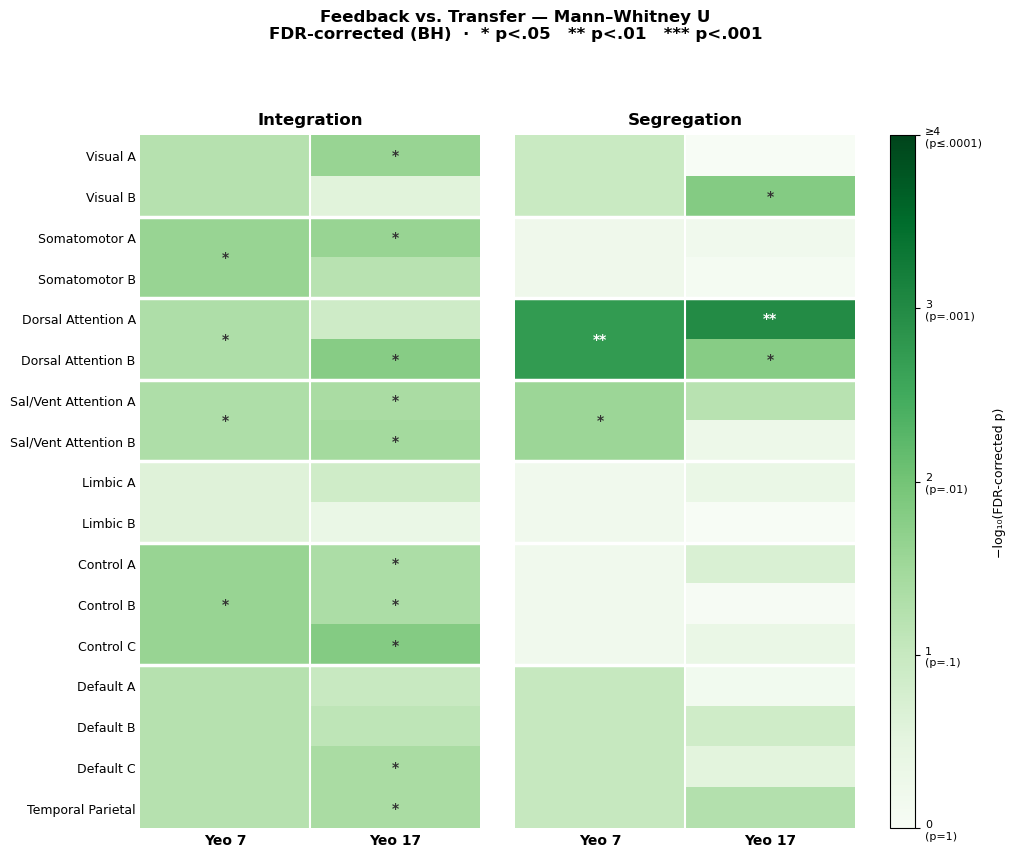

C:\Users\tesni\AppData\Local\Temp\ipykernel_3612\696151542.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


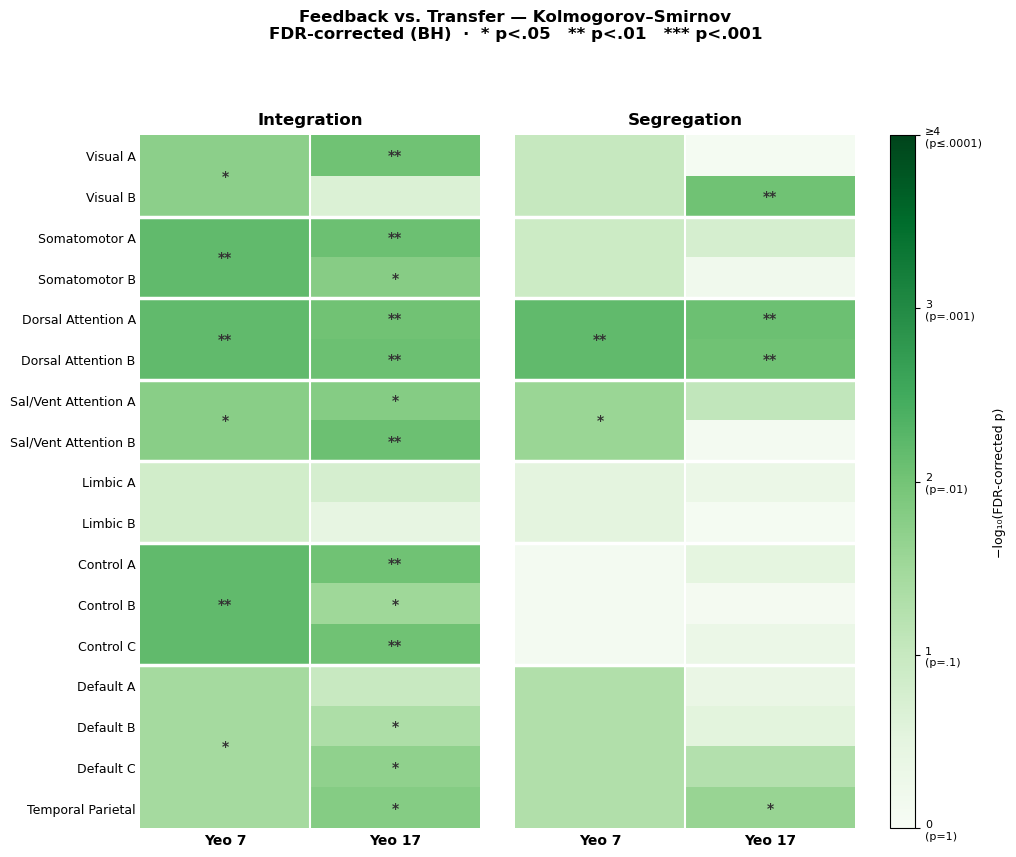

In [19]:
def make_side_by_side(test_col, test_label, out_fname):
    fig = plt.figure(figsize=(10, 9))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[4, 4, 0.3], wspace=0.15, figure=fig)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    cax  = fig.add_subplot(gs[0, 2])

    for ax, (metric, metric_label) in zip(axes, [
        ("integration_r", "Integration"),
        ("segregation_r", "Segregation"),
    ]):
        mat, stars7, stars17 = _build_matrix(test_col, metric)
        ax.imshow(mat, cmap=CMAP, norm=NORM, aspect="auto")

        for y, c, s, v in stars7:
            color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
            ax.text(c, y, s, ha="center", va="center", fontsize=10, fontweight="bold", color=color)
        for r, c, s, v in stars17:
            color = "white" if (not np.isnan(v) and v > 2.5) else "#333"
            ax.text(c, r, s, ha="center", va="center", fontsize=10, fontweight="bold", color=color)

        for b in YEO17_SEPARATORS:
            ax.axhline(b, color="white", lw=2.5, zorder=5)
        ax.axvline(0.5, color="white", lw=1.5, zorder=5)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Yeo 7", "Yeo 17"], fontsize=10, fontweight="bold")
        ax.tick_params(axis="x", length=0)
        ax.set_yticks(range(17))
        ax.set_yticklabels([_YEO17_NAME_MAP[n] for n in _YEO17_ORDER], fontsize=9)
        ax.tick_params(axis="y", length=0)
        ax.spines[:].set_visible(False)
        ax.set_title(metric_label, fontsize=12, fontweight="bold", pad=8)

    axes[1].set_yticklabels([])  # hide duplicate y-labels on right panel

    cb = plt.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=CMAP), cax=cax)
    cb.set_label("−log₁₀(FDR-corrected p)", fontsize=9, labelpad=8)
    cb.set_ticks([0, 1, 2, 3, 4])
    cb.set_ticklabels(["0\n(p=1)", "1\n(p=.1)", "2\n(p=.01)", "3\n(p=.001)", "≥4\n(p≤.0001)"], fontsize=8)

    fig.suptitle(
        f"Feedback vs. Transfer — {test_label}\n"
        "FDR-corrected (BH)  ·  * p<.05   ** p<.01   *** p<.001",
        fontsize=12, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    plt.savefig(out_fname, dpi=300, bbox_inches="tight")
    plt.show()

make_side_by_side("mw_p_corr", "Mann–Whitney U", os.path.join(FIGURES_DIR, "recap_mw.pdf"))
make_side_by_side("ks_p_corr", "Kolmogorov–Smirnov", os.path.join(FIGURES_DIR, "recap_ks.pdf"))


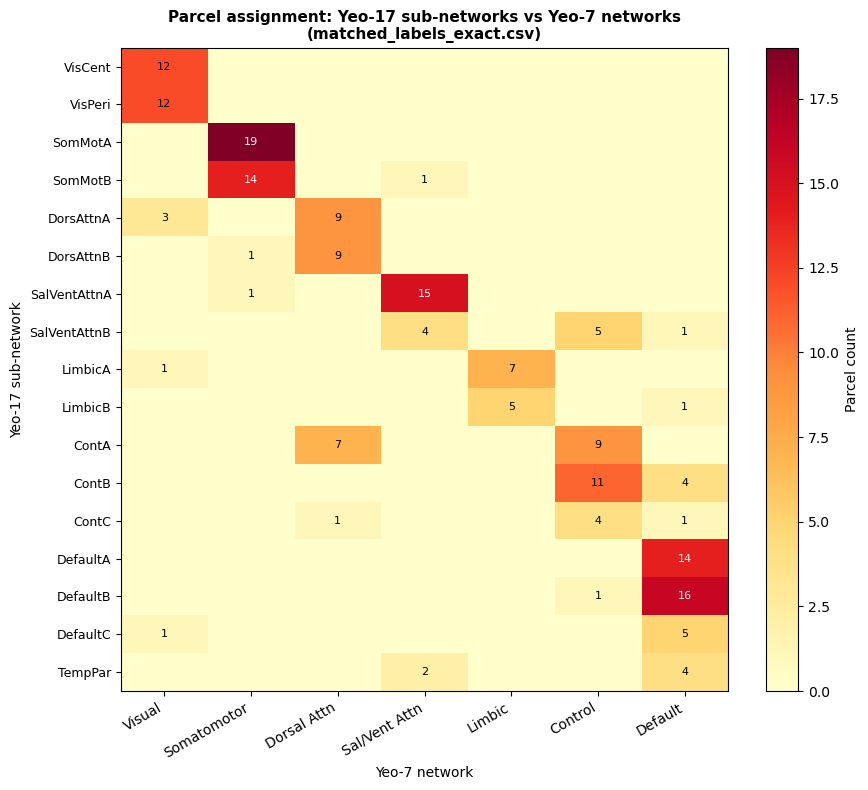

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_lookup = pd.read_csv("../utils/matched_labels_exact.csv")

# Extract network names from label strings
def yeo7_net(name):
    m = re.match(r'7Networks_[LR]H_([A-Za-z]+)', str(name))
    return m.group(1) if m else None

def yeo17_net(label):
    m = re.match(r'17Networks_[LR]H_(\w+?)_', str(label))
    return m.group(1) if m else None

df_lookup['yeo7']  = df_lookup['ROI Name'].apply(yeo7_net)
df_lookup['yeo17'] = df_lookup['label_df2'].apply(yeo17_net)

YEO17_ORDER = [
    "VisCent", "VisPeri", "SomMotA", "SomMotB",
    "DorsAttnA", "DorsAttnB", "SalVentAttnA", "SalVentAttnB",
    "LimbicA", "LimbicB", "ContA", "ContB", "ContC",
    "DefaultA", "DefaultB", "DefaultC", "TempPar",
]
YEO7_ORDER  = ["Vis", "SomMot", "DorsAttn", "SalVentAttn", "Limbic", "Cont", "Default"]
YEO7_LABELS = {
    "Vis": "Visual", "SomMot": "Somatomotor", "DorsAttn": "Dorsal Attn",
    "SalVentAttn": "Sal/Vent Attn", "Limbic": "Limbic",
    "Cont": "Control", "Default": "Default",
}

ct = (
    pd.crosstab(df_lookup['yeo17'], df_lookup['yeo7'])
    .reindex(index=YEO17_ORDER, columns=YEO7_ORDER, fill_value=0)
)
ct.columns = [YEO7_LABELS[c] for c in ct.columns]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(ct.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index, fontsize=9)

vmax = ct.values.max()
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=8, color="white" if v > 0.65 * vmax else "black")

plt.colorbar(im, ax=ax, label="Parcel count")
ax.set_xlabel("Yeo-7 network", fontsize=10)
ax.set_ylabel("Yeo-17 sub-network", fontsize=10)
ax.set_title(
    "Parcel assignment: Yeo-17 sub-networks vs Yeo-7 networks\n(matched_labels_exact.csv)",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "yeo17_vs_yeo7_assignment_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()
